# Thermal State Preparation of the Schwinger Model
**Ultimate Goal**: Prepare a thermal state
$$e^{-\beta H} / Z$$
approximately for a large system.

## Basic Imports
From Mark Rudner's *Implementations in Quantum Information* course.

In [1]:
# For circuit setup
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter

# For transpilation
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# For backends and running circuits via Sampler
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService

# For math and data analysis
import math
import numpy as np
from numpy import pi
from matplotlib import pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

## Backend Setup

In [2]:
# Set up a backend that runs a noiseless simulator
from qiskit_aer import AerSimulator
backend = AerSimulator()

# from qiskit_ibm_runtime.fake_provider import FakeMarrakesh
# backend = FakeMarrakesh()

## Transpiler Setup

In [3]:
# Create the "pass manager" that will perform the transpilation
pm = generate_preset_pass_manager(backend=backend, optimization_level=0)

## Schwinger Hamiltonian
The following function creates the Schwinger model Hamiltonian as a SparsePauliOp.
$$H = H_{kin} + H_{mass} + H_{elec}$$
where
$$H_{kin} \equiv \frac{1}{2a} \sum_{n = 0}^{L - 2} (\sigma_n^{+} \sigma_{n+1}^{-} + \sigma_{n+1}^{+} \sigma_n^{-})$$
$$H_{mass} \equiv m \sum_{n=0}^{L-1} O_n, O_n \equiv (-1)^n \frac{\sigma_n^z + 1}{2a}$$
$$H_{elec} \equiv \frac{a}{2} \sum_{n=0}^L E_n^2, E_n \equiv e(l_0 + \frac{1}{2} \sum_{j=0}^{n-1}(\sigma_j^z + (-1)^j)$$

a: lattice space

n: index of lattice position $x = na$

L: number of fermion sites = 2 * N

N: number of physical sites in the stagger fermion formulation

$\sigma^{\pm} = (\sigma_x \pm i\sigma_y)/2)$: creation/annihilation operators

We set $l_0 = 0$.

In [4]:
def get_schwinger_hamiltonian(L: int, m: float, e: float, a: float, include_shifts: bool = True) -> SparsePauliOp:
    if L <= 0:
        raise ValueError("L must be >= 1.")
    if a == 0:
        raise ValueError("a must be nonzero.")
    
    terms = []

    # Kinetic term
    ## H_kin = sum_{i=0}^{L-2} (1/(4a)) (X_i X_{i+1} + Y_i Y_{i+1})
    kin_coeff = 1.0 / (4.0 * a)
    for i in range(L - 1):
        terms.append(("XX", [i, i + 1], kin_coeff))
        terms.append(("YY", [i, i + 1], kin_coeff))

    # Mass term
    ## H_mass = sum_i m * (-1)^i * (Z_i + I)/(2a)
    for i in range(L):
        coeff = m * ((-1) ** i) / (2.0 * a)
        terms.append(("Z", [i], coeff))
        if include_shifts: # global energy shift
            terms.append(("I", [0], coeff))

    # Electric term
    ## E_i = (e/2) (S_i + C_i),  S_i = sum_{j<i} Z_j,  C_i = sum_{j<i} (-1)^j
    ## E_i^2 = (e^2/4) [ S_i^2 + 2 C_i S_i + C_i^2 ]
    ## S_i^2 = i*I + 2 sum_{j<k<i} Z_j Z_k
    base_I = (a / 2.0) * (e**2 / 4.0)
    zz_coeff = (a * e**2) / 4.0
    z_per_link_unit = (a * e**2) / 4.0

    for i in range(1, L + 1):
        # C_i = sum_{j=0}^{i-1} (-1)^j = 1 if i is odd else 0
        C = i % 2

        # Identity from i*I + C^2*I
        if include_shifts:
            terms.append(("I", [0], base_I * (i + C))) # since C^2 = C for C in {0, 1}

        # linear Z terms: (a/2)*(e^2/4)*(2 C) * sum_{j<i} Z_j = (a e^2/4)*C * sum_{j<i} Z_j
        if C == 1:
            for j in range(i):
                terms.append(("Z", [j], z_per_link_unit))

        # ZZ terms: (a/2)*(e^2/4)*(2) * sum_{j<k<i} Z_j Z_k = (a e^2/4) * sum_{j<k<i} Z_j Z_k
        for j in range(i):
            for k in range(j + 1, i):
                terms.append(("ZZ", [j, k], zz_coeff))

    H = SparsePauliOp.from_sparse_list(terms, num_qubits = L)
    return H.simplify()

### Checking Hamiltonian construction

In [5]:
# Parameters
L = 6
a = 1.0
m = 0.5
e = 1.0

H = get_schwinger_hamiltonian(L, m, e, a)
H_dense = H.to_matrix()

vals_all = np.linalg.eigvals(H_dense)
vals_all = np.real_if_close(vals_all, tol=1e5) # removes tiny imaginary parts
vals_all = np.asarray(vals_all, dtype = np.complex128)
vals_all

array([ 2.20385406+0.j,  3.17706422+0.j,  4.09554717+0.j,  4.41861399+0.j,
        5.77348826+0.j,  6.83143231+0.j, 12.07124027+0.j,  7.8564808 +0.j,
        8.77915666+0.j,  6.84784252+0.j,  7.75458251+0.j,  5.47470321+0.j,
       -2.17935655+0.j,  6.37383893+0.j, -0.43062036+0.j,  4.50897349+0.j,
        5.19403296+0.j,  4.29488609+0.j,  3.73903943+0.j, -1.06201148+0.j,
        3.4280484 +0.j,  4.60846576+0.j,  4.32714866+0.j,  4.10795759+0.j,
        3.87675283+0.j, -0.45117005+0.j,  0.50902446+0.j, -0.36291496+0.j,
       -0.22088833+0.j,  2.57736812+0.j,  2.53636296+0.j,  3.32407732+0.j,
       -0.06897418+0.j, -0.02267936+0.j, -0.04709256+0.j,  3.08824238+0.j,
        1.28079586+0.j,  2.91339512+0.j,  1.441233  +0.j,  2.71617821+0.j,
        1.64410997+0.j,  2.6735862 +0.j,  0.80051069+0.j,  0.69516238+0.j,
        0.64717163+0.j,  0.64799083+0.j,  0.88592822+0.j,  0.90025545+0.j,
        1.11042683+0.j,  1.17745058+0.j,  1.79175206+0.j,  1.40791377+0.j,
        1.52841255+0.j,  

In [6]:
# Comparing with reference eigenvalues
given = np.asarray([-2.17935655, -0.45117005, -0.36291496, -0.22088833, -0.06897418, -0.02267936,
  0.64717163,  0.64799083,  0.80051069,  1.40791377,  1.52841255,  1.69044329,
  1.79807205,  1.86945912,  1.92068802,  2.12033848,  2.6735862,   2.71617821,
  3.87675283,  4.60846576], dtype=np.complex128)

def format_c(z: complex, prec=8):
    return f"{z.real:.{prec}e}{z.imag:+.{prec}e}j"

remaining = list(range(len(vals_all)))
ordered = []

for lam in given:
    # finding nearest among remaining
    rem_vals = vals_all[remaining]
    j = int(np.argmin(np.abs(rem_vals - lam)))
    idx = remaining.pop(j)
    ordered.append(vals_all[idx])

ordered = np.array(ordered, dtype = np.complex128)
for z in ordered:
    print(format_c(z, prec=8))

-2.17935655e+00+0.00000000e+00j
-4.51170055e-01+0.00000000e+00j
-3.62914957e-01+0.00000000e+00j
-2.20888333e-01+0.00000000e+00j
-6.89741845e-02+0.00000000e+00j
-2.26793560e-02+0.00000000e+00j
6.47171627e-01+0.00000000e+00j
6.47990832e-01+0.00000000e+00j
8.00510689e-01+0.00000000e+00j
1.40791377e+00+0.00000000e+00j
1.52841255e+00+0.00000000e+00j
1.69044329e+00+0.00000000e+00j
1.79807205e+00+0.00000000e+00j
1.86945912e+00+0.00000000e+00j
1.92068802e+00+0.00000000e+00j
2.12033848e+00+0.00000000e+00j
2.67358620e+00+0.00000000e+00j
2.71617821e+00+0.00000000e+00j
3.87675283e+00+0.00000000e+00j
4.60846576e+00+0.00000000e+00j


## Liouvillian Operator
The Lindblad master equation for $\rho_S$ (system density matrix) can be written as:
$$\frac{d\rho_S(t)}{dt} = -i[H_S, \rho_S(t)] + a^2 \sum_{x_1, x_2} D(x_1 - x_2) \times (L(x_2)\rho_SL^{\dagger}(x_1) - \frac{1}{2} \{L^{\dagger}(x_1)L(x_2), \rho_S\}).$$

$D(x_1 - x_2)$: environment correlator

$L(na) = O(n) - \frac{1}{4T} [H_S, O(n)]$: Lindblad operators

$O(n) = (-1)^n \frac{\sigma_z(n) + 1}{2a}$

The Lindblad master equation can be written in terms of a Liouvillian superoperator as:
$$\frac{d \rho}{dt} \equiv \mathcal{L} \rho.$$

In [7]:
def O_n(n: int, L: int, a: float) -> SparsePauliOp:
    """
    n: site
    L: number of sites
    """
    s = (-1)**n

    I_label = "I" * L

    chars = ["I"] * L
    chars[-1 - n] = "Z" # rightmost is qubit 0
    Z_label = "".join(chars)

    O = SparsePauliOp.from_list([
        (I_label, s/(2.0*a)),
        (Z_label, s/(2.0*a)),
    ])

    return O.simplify()

In [8]:
def L_n(n: int, H: SparsePauliOp, L: int, a: float, T: float) -> SparsePauliOp:
    O = O_n(n, L, a)
    comm = H @ O - O @ H

    return (O - (1.0/(4.0*T)) * comm).simplify()

### Environment Correlator $D(x)$
Regarding the environmental correlator, $x_1 = n_1 a$ and $x_2 = n_2 a$ are discrete spatial coordinates.

For short range correlations, use a delta function:
$$D_{\delta}(x) = D_0 \delta_{0x}.$$

For intermediate-range correlations, use a Gaussian:
$$D_G(x) = D_0 \exp(-\frac{x^2}{2\sigma^2}) \equiv D_0 G(x, \sigma).$$

For long-range correlations, use a constant function:
$$D_C(x) = D_0.$$

In [9]:
def D_matrix(L: int, a: float, kind: str, D0: float, sigma: float | None = None):
    D = np.zeros((L, L), dtype = float)
    for n1 in range(L):
        for n2 in range(L):
            x = (n1 - n2) * a
            if kind == "delta":
                D[n1, n2] = D0 if n1 == n2 else 0.0
            elif kind == "gaussian":
                assert sigma is not None
                D[n1, n2] = D0 * np.exp(-(x*x) / (2.0*sigma*sigma))
            elif kind == "const":
                D[n1, n2] = D0
            else:
                raise ValueError("kind must be delta/gaussian/const")
    return D

### Building the Liouvillian superoperator
In building the Liouvillian superoperator, the following ways of rewriting the Lindblad equation are used:

For the Hamiltonian part,
$$-i[H, \rho] \rightarrow -i (I \otimes H - H^T \otimes I) vec(\rho)$$

For the dissipator part,
$$a^2 \sum_{x_1, x_2} D(x_1 - x_2) [(L^{\dagger}(x_1))^T \otimes L(x_2) - \frac{1}{2}(I \otimes M) - \frac{1}{2} (M^T \otimes I)] vec(\rho)$$
where $M = L^{\dagger}(x_1)L(x_2).$

We can do this thanks to the following identity:
$$vec(A \rho B) = (B^T \otimes A) vec(\rho).$$

This way, the Lindblad equation is a linear ODE:
$$\frac{d}{dt}|\rho> = \mathcal{L}|\rho>$$

In [10]:
def build_liouvillian(H_op: SparsePauliOp, L_ops: list[SparsePauliOp], D: np.ndarray, a_lat: float) -> sp.csr_matrix:
    H = H_op.to_matrix(sparse=True).tocsr()
    d = H.shape[0]
    I = sp.identity(d, format="csr")

    # -i [H, ρ]  ->  -i (I⊗H - H^T⊗I) vec(ρ)
    Lsuper = -1j * (sp.kron(I, H, format = "csr") - sp.kron(H.T, I, format = "csr"))

    Lmats = [Lop.to_matrix(sparse=True).tocsr() for Lop in L_ops] # Lindblad matrices

    # Dissipator: a^2 sum_{n1,n2} D_{n1n2} ( L(n2) ρ L†(n1) - 1/2 {L†(n1)L(n2), ρ} )
    pref = (a_lat**2)
    for n1 in range(len(Lmats)):
        L1 = Lmats[n1]
        L1dag = L1.getH()
        L1star = L1.conjugate() # (L†)^T == L*

        for n2 in range(len(Lmats)):
            w = pref * D[n1, n2]
            if w == 0.0:
                continue

            L2 = Lmats[n2]
            M = (L1dag @ L2).tocsr()

            term_jump = sp.kron(L1star, L2, format = "csr")
            term_ac1 = sp.kron(I, M, format = "csr")
            term_ac2 = sp.kron(M.T, I, format = "csr")

            Lsuper += w * (term_jump - 0.5 * term_ac1 - 0.5*term_ac2)

    return Lsuper.tocsr()

#### Checking Liouvillian superoperator construction

In [11]:
# Parameters
L = 4
a_lat = 1.0
T = 5.0
m = 0.5
e = 0.71

H = get_schwinger_hamiltonian(L, m, e, a_lat)

L_ops = [L_n(n=n, H=H, L=L, a=a_lat, T=T) for n in range(L)]

D = D_matrix(L, a_lat, kind="const", D0 = 1.0)

Lsuper = build_liouvillian(H, L_ops, D, a_lat)
Ld = Lsuper.toarray()

vals = np.linalg.eigvals(Ld)
vals = sorted(vals, key = lambda z: z.real, reverse = True)

In [12]:
# Comparing with given eigenvalues
vals_all = np.linalg.eigvals(Lsuper.toarray())

given = np.asarray([
    -3.27165339e-17+1.84374375e-17j, -9.24271504e-17+1.23084462e-16j,
    -5.49683823e-02-4.47083132e-01j, -5.49683823e-02+4.47083132e-01j,
    -6.06370298e-02+1.28174296e-02j, -6.06370298e-02-1.28174296e-02j,
    -1.07540816e-01+4.64566856e-01j, -1.07540816e-01-4.64566856e-01j,
    -1.08535026e-01-9.99650752e-17j, -1.65308941e-01+8.96133803e-17j,
    -3.13915019e-01-6.79522482e-17j, -4.17773467e-01-6.25506542e-16j,
    -4.60634662e-01+3.60048712e-02j, -4.60634662e-01-3.60048712e-02j,
    -4.77113769e-01-3.74875107e-01j, -4.77113769e-01+3.74875107e-01j,
    -1.05896504e+00-1.24389324e-15j, -1.47677327e+00-1.94707262e+00j,
    -1.47677327e+00+1.94707262e+00j, -1.48778673e+00+1.45821468e-17j,
    -1.53058783e+00+1.65481866e+00j, -1.53058783e+00-1.65481866e+00j,
    -1.65265405e+00+1.89292675e+00j, -1.65265405e+00-1.89292675e+00j,
    -1.68118664e+00-1.40596425e+00j, -1.68118664e+00+1.40596425e+00j,
    -1.68583228e+00+1.16965604e+00j, -1.68583228e+00-1.16965604e+00j,
    -1.74045706e+00-1.46933933e+00j, -1.74045706e+00+1.46933933e+00j,
    -1.75757329e+00-1.51180342e+00j, -1.75757329e+00+1.51180342e+00j,
    -1.87056050e+00-1.36547776e+00j, -1.87056050e+00+1.36547776e+00j,
    -7.75733831e+00+2.55247828e+00j, -7.75733831e+00-2.55247828e+00j
], dtype=np.complex128)

def format_c(z: complex, prec=8):
    return f"{z.real:.{prec}e}{z.imag:+.{prec}e}j"

vals_all = np.asarray(np.linalg.eigvals(Lsuper.toarray()), dtype = np.complex128)

remaining = list(range(len(vals_all)))
ordered = []

for lam in given:
    # finding nearest among remaining
    rem_vals = vals_all[remaining]
    j = int(np.argmin(np.abs(rem_vals - lam)))
    idx = remaining.pop(j)
    ordered.append(vals_all[idx])

ordered = np.array(ordered, dtype = np.complex128)
for z in ordered:
    print(format_c(z, prec=8))

0.00000000e+00+0.00000000e+00j
0.00000000e+00+0.00000000e+00j
-5.49683823e-02-4.47083132e-01j
-5.49683823e-02+4.47083132e-01j
-6.06370298e-02+1.28174296e-02j
-6.06370298e-02-1.28174296e-02j
-1.07540816e-01+4.64566856e-01j
-1.07540816e-01-4.64566856e-01j
-1.08535026e-01-8.46920449e-16j
-1.65308941e-01-7.20312881e-16j
-3.13915019e-01-4.36101958e-16j
-4.17773467e-01-3.32741647e-16j
-4.60634662e-01+3.60048712e-02j
-4.60634662e-01-3.60048712e-02j
-4.77113769e-01-3.74875107e-01j
-4.77113769e-01+3.74875107e-01j
-1.05896504e+00-8.26625220e-16j
-1.47677327e+00-1.94707262e+00j
-1.47677327e+00+1.94707262e+00j
-1.48778673e+00+2.09896398e-16j
-1.53058783e+00+1.65481866e+00j
-1.53058783e+00-1.65481866e+00j
-1.65265405e+00+1.89292675e+00j
-1.65265405e+00-1.89292675e+00j
-1.68118664e+00-1.40596425e+00j
-1.68118664e+00+1.40596425e+00j
-1.68583228e+00+1.16965604e+00j
-1.68583228e+00-1.16965604e+00j
-1.74045706e+00-1.46933933e+00j
-1.74045706e+00+1.46933933e+00j
-1.75757329e+00-1.51180342e+00j
-1.7575732

## Building J Operator
The quantum circuit below reproduces the Lindblad equation when $\Delta t \rightarrow 0$.
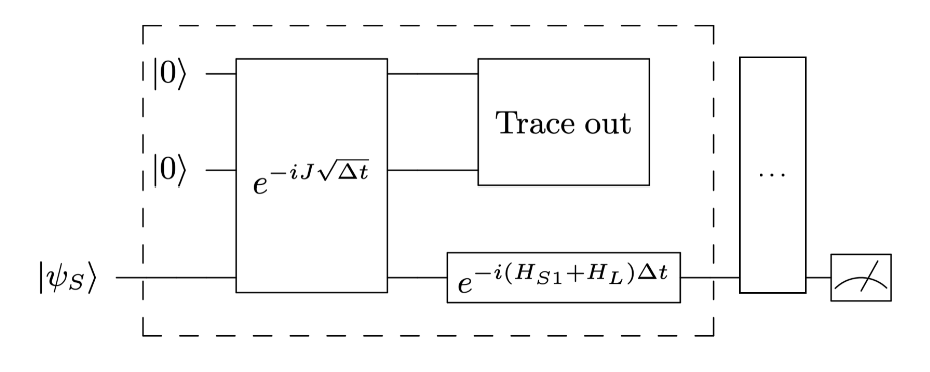

Here, J is defined as:
$$\begin{pmatrix} 0 & L_1^{\dagger} & ... & L_m^{\dagger} \\ L_1 & 0 & ... & 0 \\ \vdots & \vdots &  & \vdots \\ L_m & 0 & ... & 0 \end{pmatrix}$$

where the $L$'s are the Lindblad operators defined previously.

The $|0\rangle$ qubits are auxiliary qubits that help simulate the non-unitary evolution of the Lindblad equation. Adding these auxiliary qubits makes the whole system evolve unitarily. They are traced out after every time step.

### Helper Functions

In [13]:
def int_to_bits(idx: int, nbits: int) -> list[int]:
    """
    Extracts an integer's binary digits as a list of 0/1 values.
    """
    if idx < 0 or idx >= (1 << nbits):
        raise ValueError(f"idx = {idx} out of range for nbits = {nbits}")
    return [(idx >> q) & 1 for q in range(nbits)] # q = 0 is qubit 0

def int_to_bitstring(idx: int, nbits: int) -> str:
    """
    Converts an integer to binary as a string.
    """
    bits = int_to_bits(idx, nbits)
    return "".join(str(bits[q]) for q in reversed(range(nbits)))

In [14]:
def ketbra_1q(ket: int, bra: int) -> SparsePauliOp:
    """
    |0><0| = 0.5(I + Z)
    |1><1| = 0.5(I - Z)
    |0><1| = 0.5(X + iY)
    |1><0| = 0.5(X - iY)
    """
    if ket == 0 and bra == 0:
        return SparsePauliOp.from_list([("I", 0.5), ("Z", 0.5)])
    if ket == 1 and bra == 1:
        return SparsePauliOp.from_list([("I", 0.5), ("Z", -0.5)])
    if ket == 0 and bra == 1:
        return SparsePauliOp.from_list([("X", 0.5), ("Y", 0.5j)])
    if ket == 1 and bra == 0:
        return SparsePauliOp.from_list([("X", 0.5), ("Y", -0.5j)])
    raise ValueError("ket and bra must be 0 or 1")

def ketbra_from_bits(ket_bits: list[int], bra_bits: list[int]) -> SparsePauliOp:
    """
    Returns a SparsePauliOp for |ket><bra| on n qubits.
    ket_bits[q] corresponds to qubit q

    |ket><bra| = ⊗_{q=0}^{n-1} (|k_q><b_q|)
    """
    if len(ket_bits) != len(bra_bits):
        raise ValueError("ket_bits and bra_bits must have same length")
    n = len(ket_bits)
    if n == 0:
        raise ValueError("Need at least 1 qubit")

    op = ketbra_1q(ket_bits[n-1], bra_bits[n-1])
    for q in reversed(range(n-1)): # q = n-2 ... 0
        op = op.tensor(ketbra_1q(ket_bits[q], bra_bits[q]))
    return op.simplify()

def ketbra_from_ints(ket: int, bra: int, nbits: int) -> SparsePauliOp:
    """
    Straight from an integer to a tensor product.
    """
    return ketbra_from_bits(int_to_bits(ket, nbits), int_to_bits(bra, nbits))

### Building J operator

In [15]:
def build_J_operator(L_ops: list[SparsePauliOp], n_sys: int) -> SparsePauliOp:
    """
    J = sum_{j=1}^m ( |j><0| ⊗ L_j + |0><j| ⊗ L_j^† )
    """
    m = len(L_ops)
    n_aux = math.ceil(math.log2(m+1))
    if (1 << n_aux) < (m + 1):
        raise ValueError("n_aux sizing failed")

    total_qubits = n_aux + n_sys
    J = SparsePauliOp.from_list([("I" * total_qubits, 0.0)])

    for j, Lj in enumerate(L_ops, start=1):
        if j > m:
            break

        ket_j_bra_0 = ketbra_from_ints(j, 0, n_aux) # |j><0|
        ket_0_bra_j = ketbra_from_ints(0, j, n_aux) # |0><j|

        Lj_dag = Lj.adjoint()

        J += ket_j_bra_0.tensor(Lj)
        J += ket_0_bra_j.tensor(Lj_dag)

    return J.simplify()

### Checking J Operator Construction
Block (j, 0) in the aux basis should equal $L_j$, and block (0, j) should equal $L^{\dagger}_j$ with all other blocks zero.

The block structure should match:
$$J[j,0] = L_j$$
$$J[0,j] = L^{\dagger}_j$$

In [16]:
def check_J_blocks(J: SparsePauliOp, L_ops: list[SparsePauliOp], n_sys: int):
    m = len(L_ops)
    n_aux = J.num_qubits - n_sys
    d_aux = 2**n_aux
    d_sys = 2**n_sys

    Jm = J.to_matrix()
    Lmats = [L.to_matrix() for L in L_ops]

    def block(a, b):
        # aux block (a, b)
        r0, r1 = a*d_sys, (a+1)*d_sys
        c0, c1 = b*d_sys, (b+1)*d_sys
        return Jm[r0:r1, c0:c1]

    # Checking |j><0| blocks
    for j in range(1, m+1):
        err = np.linalg.norm(block(j, 0) - Lmats[j-1])
        print(f"||J[{j},0] - L_{j}|| =", err)

    # Checking |0><j| blocks
    for j in range(1, m+1):
        err = np.linalg.norm(block(0, j) - Lmats[j-1].conj().T)
        print(f"||J[0,{j}] - L_{j}^†|| =", err)

In [17]:
L = 4
a_lat = 1.0
m_mass = 0.5
e_coup = 0.71
T = 5.0
    
H = get_schwinger_hamiltonian(L, m_mass, e_coup, a_lat)
L_ops = [L_n(n=n, H=H, L=L, a=a_lat, T=T) for n in range(L)]
    
J = build_J_operator(L_ops = L_ops, n_sys = H.num_qubits)

check_J_blocks(J, L_ops, n_sys = H.num_qubits)

||J[1,0] - L_1|| = 9.813077866773595e-18
||J[2,0] - L_2|| = 1.3877787807814457e-17
||J[3,0] - L_3|| = 1.3877787807814457e-17
||J[4,0] - L_4|| = 9.813077866773595e-18
||J[0,1] - L_1^†|| = 9.813077866773595e-18
||J[0,2] - L_2^†|| = 1.3877787807814457e-17
||J[0,3] - L_3^†|| = 1.3877787807814457e-17
||J[0,4] - L_4^†|| = 9.813077866773595e-18


The Jong et al. (2021) paper assumes
$$\sum_j L_j \rho L_j^{\dagger} - \frac{1}{2}\{L_j^{\dagger}L_j, \rho\}$$
while mine is
$$a^2 \sum_{x_1, x_2} D(x_1 - x_2) \times (L(x_2)\rho_SL^{\dagger}(x_1) - \frac{1}{2} \{L^{\dagger}(x_1)L(x_2), \rho_S\}).$$

For non-diagonal environmental correlations (not delta functions), I need to diagonalize D before constructing the J operator. And then construct effective Lindblad operators.

$$D_{n_1, n_2} = \sum_{\alpha}\lambda_{\alpha} v_{n_1\alpha}v^{*}_{n_2\alpha}$$

$$\tilde{L}_{\alpha} = a \sqrt{\lambda_{\alpha}} \sum_n v^{*}_{n\alpha} L(n)$$

In [18]:
# Diagonalizing the environment correlation matrix
def diagonalized_lindblad_ops(
    raw_L_ops: list[SparsePauliOp],
    D: np.ndarray,
    a_lat: float,
    tol: float = 1e-12,
) -> list[SparsePauliOp]:
    """
    Convert correlated dissipator

        a^2 sum_{n1,n2} D[n1,n2]
        ( L[n2] rho L[n1]^dag - 1/2 {L[n1]^dag L[n2], rho} )

    into diagonal Lindblad form

        sum_alpha ( L_eff[alpha] rho L_eff[alpha]^dag
        - 1/2 {L_eff[alpha]^dag L_eff[alpha], rho} ).
    """
    D = np.asarray(D, dtype=complex)

    if D.shape != (len(raw_L_ops), len(raw_L_ops)):
        raise ValueError("D must have shape (len(raw_L_ops), len(raw_L_ops))")

    # D should be Hermitian positive semidefinite
    if not np.allclose(D, D.conj().T, atol=1e-10):
        raise ValueError("D must be Hermitian for Lindblad diagonalization")

    evals, evecs = np.linalg.eigh(D)

    eff_ops = []

    for alpha, lam in enumerate(evals):
        if lam < -tol:
            raise ValueError(f"D has negative eigenvalue {lam}; not completely positive")

        if lam <= tol:
            continue

        coeff = a_lat * np.sqrt(lam)

        # eigenvector column alpha: evecs[n, alpha]
        Lop_eff = None

        for n, Lop_n in enumerate(raw_L_ops):
            c = coeff * np.conj(evecs[n, alpha])

            if abs(c) <= tol:
                continue

            term = c * Lop_n

            if Lop_eff is None:
                Lop_eff = term
            else:
                Lop_eff = Lop_eff + term

        if Lop_eff is not None:
            eff_ops.append(Lop_eff.simplify())

    return eff_ops

#raw_L_ops = [L_n(n, H, L, a, T) for n in range(L)]
#D = D_matrix(L, a, kind="gaussian", D0=D0, sigma=sigma)
#
#effective_L_ops = diagonalized_lindblad_ops(raw_L_ops, D, a)
#
#J = build_J_operator(effective_L_ops, n_sys=L)

## Creating the Quantum Circuit
The dissipator is a sum of independent jump channels, and the circuit only reproduces the Lindblad equation to first order in $\Delta t$ anyway, so we Trotter-split it
$$e^{\mathcal{L}\Delta t}\approx \prod_{k} e^{\mathcal{L}_k \Delta t}$$
and dilate **one jump at a time** with the minimal single-ancilla block
$$J_k=\begin{pmatrix} 0 & L_k^\dagger \\ L_k & 0\end{pmatrix},$$
resetting and reusing the same ancilla qubit between each $k$. This is the standard Stinespring/collision-model dilation. The ancilla is what makes the non-unitary Lindblad evolution unitary on the enlarged space; resetting it after each jump is the partial trace.

**Why not dilate all $m$ jumps at once.** The obvious alternative packs every Lindblad operator into one big block operator
$$J = \begin{pmatrix} 0 & L_1^{\dagger} & ... & L_m^{\dagger} \\ L_1 & 0 & ... & 0 \\ \vdots & \vdots &  & \vdots \\ L_m & 0 & ... & 0 \end{pmatrix}$$
whose first row/column holds all $m$ Lindblad operators. That costs on two fronts:
1. **Width**: the ancilla has to index $m+1$ states, so it becomes a $\lceil \log_2(m+1)\rceil$-qubit register.
2. **Depth**: the transpiler sees $\exp(-i J \sqrt{\Delta t})$ as one big unitary over that register and synthesizes it as a black box. It doesn't exploit that each $L_j$ is a short Pauli string.

Splitting jump-by-jump drops the ancilla width from $\lceil\log_2(m+1)\rceil$ to $1$, and each $\exp(-i J_k \sqrt{\Delta t})$ becomes an ancilla-controlled rotation built directly from $L_k$'s Pauli terms (short CNOT ladders) rather than a slice of a dense unitary. This doesn't cut the *number* of coupling operations (~$m$ per step), but it cuts the per-operator cost sharply and sheds the ancilla register. Serializing the jumps adds an $O(\Delta t^2)$ splitting error — the same order as the dilation error already present — so it costs nothing in accuracy order.

In [19]:
def build_single_ancilla_circuit(
    H_op: SparsePauliOp,
    eff_L_ops: list[SparsePauliOp],
    n_sys: int,
    dt: float,
    n_steps: int,
    init_state=None,
    measure: bool = False,
    reps: int = 1,
) -> QuantumCircuit:
    """
    Build the dilation/Trotter circuit that reproduces the Lindblad equation in the
    limit dt -> 0, using a SINGLE reused ancilla qubit.

    The dissipator is split into independent single-jump channels

        exp(L dt) ~= prod_k exp(L_k dt),

    and each jump L_k is dilated with its own minimal 2x2 block

        J_k = |1><0| (x) L_k + |0><1| (x) L_k^dag      (one ancilla qubit),

    which is exactly build_J_operator([L_k], n_sys) with m = 1 -> n_aux = 1. The
    ancilla is reset (traced out) after each jump, so the same physical qubit is
    reused for every jump and every step -- no ceil(log2(m+1))-qubit aux register.

    Valid only for a memoryless (delta-in-time / Markovian) environment: reusing one
    ancilla assumes the bath keeps no memory between resets. Serializing the jumps
    adds an O(dt^2) Trotter-splitting error -- the same order as the dilation error
    already present -- so it costs nothing in accuracy order.

    One time step, with the single ancilla initialized in |0>:
        for each effective jump L_k:
            U_Jk = exp(-i J_k sqrt(dt))   on (sys + ancilla)
            reset the ancilla to |0>      (trace out -> ready for the next jump)
        U_H = exp(-i H dt)                on the system qubits

    Qubit-ordering convention: the SYSTEM register is added first, so the system
    occupies circuit qubits 0..n_sys-1 and the single ancilla is the high qubit
    n_sys. build_J_operator does ketbra_aux.tensor(L_sys), which puts the ancilla in
    the high position of each J_k, hence jk_qubits = sys_qubits + [ancilla]. Drawing
    the circuit therefore shows the system on top and the ancilla on the bottom.
    rho_vs_cycles below relies on this "system low, ancilla high" layout when it
    traces the ancilla out.

    Parameters
    ----------
    H_op       : system Hamiltonian (acts on n_sys qubits).
    eff_L_ops  : effective (D-diagonalized) jump operators, each dilated separately
                 -- see diagonalized_lindblad_ops.
    n_sys      : number of system qubits.
    dt         : Trotter time step (note U_Jk uses sqrt(dt), U_H uses dt).
    n_steps    : number of Trotter steps.
    init_state : optional initial state on the SYSTEM qubits. Accepts anything
                 qiskit's initialize() takes -- a statevector array of length
                 2**n_sys, an int, or a bitstring label (e.g. "0101"). The ancilla
                 always starts in |0>.
    measure    : if True, add a classical register and measure the system qubits.
    reps       : Trotter repetitions used when each PauliEvolutionGate is
                 synthesized into native gates (passed to LieTrotter).

    Returns
    -------
    QuantumCircuit with registers s (system) and a (1 ancilla), and optionally c.
    """
    if H_op.num_qubits != n_sys:
        raise ValueError(f"H_op acts on {H_op.num_qubits} qubits but n_sys = {n_sys}.")

    synth = LieTrotter(reps=reps)
    # One minimal single-ancilla dilation gate per effective jump operator.
    U_Jk = [
        PauliEvolutionGate(build_J_operator([Lk], n_sys=n_sys),
                           time=np.sqrt(dt), synthesis=synth)
        for Lk in eff_L_ops
    ]
    U_H = PauliEvolutionGate(H_op, time=dt, synthesis=synth)

    aux = QuantumRegister(1, "a")
    sys = QuantumRegister(n_sys, "s")
    qc = QuantumCircuit(sys, aux)          # system register first -> system on top when drawn
    sys_qubits = list(sys)
    aux_q = aux[0]
    jk_qubits = sys_qubits + [aux_q]       # system low, ancilla high (matches build_J_operator)

    if init_state is not None:
        qc.initialize(init_state, sys_qubits)
        qc.barrier()

    for _ in range(n_steps):
        for U in U_Jk:
            qc.append(U, jk_qubits)        # exp(-i J_k sqrt(dt)) on sys + ancilla
            qc.reset(aux_q)                # trace out this jump; ancilla back to |0>
        qc.append(U_H, sys_qubits)         # exp(-i H dt) on sys
        qc.barrier()

    if measure:
        creg = ClassicalRegister(n_sys, "c")
        qc.add_register(creg)
        qc.measure(sys_qubits, creg)

    return qc

### Visualizing one Trotter step

Draw ONE Trotter step (logical, pre-transpile) so the structure stays legible — the
transpiled circuit is thousands of gates and unreadable. Each dilation shows up as a
single labeled block: $m$ narrow $\exp(-iJ_k\sqrt{dt})$ blocks in series, each
touching only the one ancilla, with a `reset` on that ancilla between them, then
$\exp(-iH\,dt)$ on the system.

system qubits = 4, ancilla = 1, total = 5  --  4 exp(-iJ_k.sqrt(dt)) blocks, reset between each


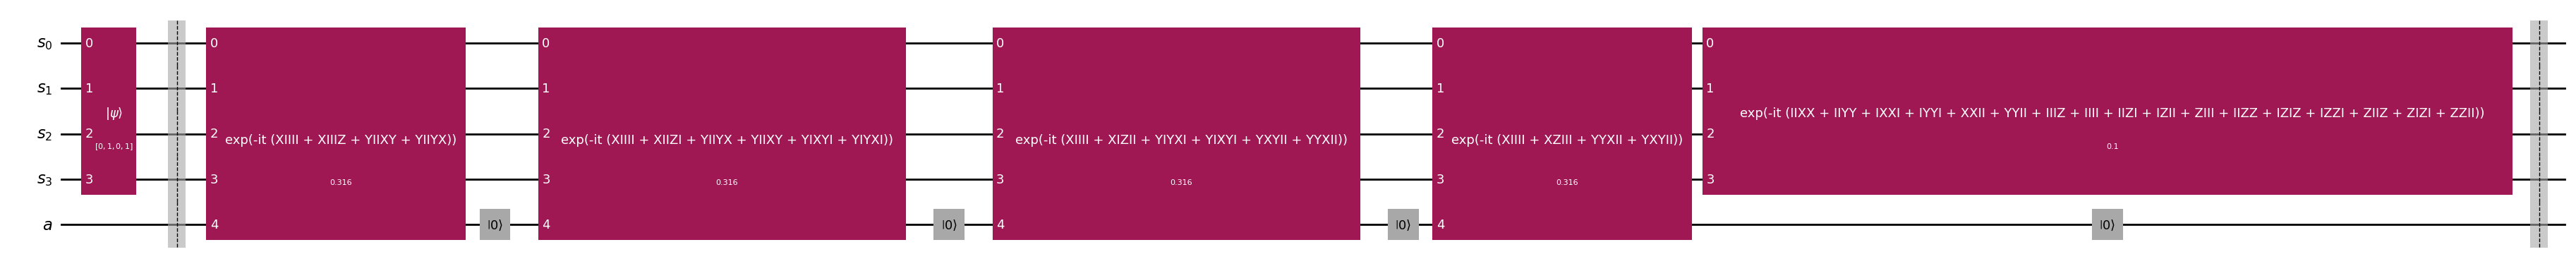

In [20]:
# --- Demo: build and draw one Trotter step of the single-ancilla circuit ---
L = 4
a_lat = 1.0
m_mass = 0.5
e_coup = 0.71
T = 5.0
dt = 0.1

H = get_schwinger_hamiltonian(L, m_mass, e_coup, a_lat)
n_sys = H.num_qubits

# Jump operators -> effective jumps. For non-delta correlations
# diagonalized_lindblad_ops handles the off-diagonal D[n1,n2] terms.
raw_L_ops = [L_n(n=n, H=H, L=L, a=a_lat, T=T) for n in range(L)]
eff_L_ops = diagonalized_lindblad_ops(
    raw_L_ops, D_matrix(L, a_lat, kind="delta", D0=1.0), a_lat)

# Initialize the system qubits. Examples (pick one):
#   init_state = "0101"                 # computational basis (bitstring)
#   init_state = 5                      # same, as an integer
#   init_state = some_numpy_statevector # length 2**n_sys, normalized
init_state = "0101"

qc = build_single_ancilla_circuit(
    H_op=H, eff_L_ops=eff_L_ops, n_sys=n_sys,
    dt=dt, n_steps=1, init_state=init_state,
)

print(f"system qubits = {n_sys}, ancilla = 1, total = {qc.num_qubits}  --  "
      f"{len(eff_L_ops)} exp(-iJ_k.sqrt(dt)) blocks, reset between each")
qc.draw("mpl", fold=-1, idle_wires=False)

# Tip: to *see* the gate-count blow-up, look at the transpiled version instead --
# it is huge, so print op counts rather than drawing it:
#   pm.run(qc.decompose(reps=6)).count_ops()
# Bump n_steps (e.g. 2) to see how a step repeats.

## Thermal State Preparation
The steady state is the Gibbs state,

$$
\rho_\mathrm{ss} = \frac{e^{-\beta H}}{Z}.
$$

The auxiliary qubits and resets in each Trotter cycle act as a synthetic bath that pumps entropy in and out until the system settles into thermal equilibrium at the temperature set by the Lindblad operators.

We'll use "enough" Trotter cycles for the initial state to relax to a steady state. Recall that the fixed point is unique and independent of the initial state. The number of "enough" cycles is set by the Liouvillian spectral gap. The nonzero eigenvalue with the largest real part is the slowest-decaying mode. The relaxation time is roughly

$$
\tau \approx \frac{1}{|\mathrm{Re}(\lambda_\mathrm{gap})|}.
$$

So, the total evolved time

$$
t = n_\mathrm{steps} \cdot dt
$$

needs to be several multiples of $\tau$. Therefore,

$$
n_\mathrm{steps} \approx \frac{(\text{a few})\,\tau}{dt}.
$$


$dt$ must be small so each cycle's first-order Trotter approximation is accurate. And, $n_\text{steps}\cdot dt$ must be large so I actually reach the steady state.

**How I'll know I've reached the thermal state"**
 - Track the fidelity $F(n) = \mathrm{Tr}\sqrt{\rho^{1/2}(n)\,\rho_\mathrm{th}\,\rho^{1/2}(n)}$ between the circuit state and the theoretical thermal state vs cycle number. When it flattens near 1, I've reached the steady state.
 - Run from a few different initial states. If they converge to the same observables, I'm at the unique fixed point.
 - Compare to the exact Gibbs state (since my system is small) -- restricted to the charge sector the dynamics can actually reach.
 - The exact steady state is the zero-eigenvalue eigenvector of the Liouvillian matrix. Reshape the steady state into a density matrix and compare to $e^{-\beta H}/Z$.

### Tracking Fidelity to the Thermal State vs Cycle Number
The observable is the **Uhlmann fidelity** between the state the circuit actually prepares and the theoretical thermal state,

$$
F(n) \;=\; \mathrm{Tr}\sqrt{\rho^{1/2}(n)\,\rho_\mathrm{th}\,\rho^{1/2}(n)},
\qquad
\rho_\mathrm{th} = \frac{e^{-H/T}}{Z},
$$

where $\rho(n)$ is the reduced system state after $n$ Lindblad/Trotter cycles (auxiliaries traced out). $F \in [0, 1]$, and $F = 1$ **iff** $\rho(n) = \rho_\mathrm{th}$. This replaces $\langle H \rangle$ as the convergence diagnostic: the energy is a single number that two very different states can share, whereas $F = 1$ pins down the *entire* density matrix. (Convention: this is the square root of qiskit's `state_fidelity`, which returns $F^2$.)

**Why there is no `Estimator` here.** $F$ is *not* a linear functional of $\rho$, so it is not a Qiskit observable and no `Estimator` can return it. Instead we read the density matrix out directly with `save_density_matrix` on an `AerSimulator(method="density_matrix")` — exact, no shots, no sampling error. A density-matrix simulation is required in any case: each cycle resets the auxiliary qubits, tracing them out, so the reduced system state is *mixed* and a statevector run would only sample one random reset trajectory.

**What to compare against — the charge sector matters.** The Lindblad operators $L(n) = O(n) - \frac{1}{4T}[H, O(n)]$ are built from $O(n)\propto\sigma_z(n)$ and commute with the total charge $\sum_n \sigma_z(n)$, which $H$ also conserves. So the dissipative dynamics **never leaves the charge sector of the initial state**: from $|0101\rangle$ ($S_z=0$) it can only reach other $S_z=0$ states. The reachable target is therefore the Gibbs state *restricted to that sector*, embedded back into the full Hilbert space — **not** the full-Hilbert-space Gibbs state. We plot $F$ against both: it should climb toward 1 for the sector target, while the full-Gibbs curve saturates far below 1, at the overlap between the sector Gibbs state and the full one. To actually target the full Gibbs state, average over initial states from every charge sector.

In [21]:
# ============================================================
#  Observable: fidelity to the theoretical thermal state
#      F(rho, sigma) = Tr sqrt( rho^{1/2} sigma rho^{1/2} )
# ============================================================
# F is NONLINEAR in rho, so it is not a Qiskit observable and no Estimator can
# return it -- we read rho out exactly with save_density_matrix instead (next cell).
from qiskit.quantum_info import DensityMatrix, partial_trace

# Exact (shot-free) density-matrix simulator. Needed whatever the observable: each
# cycle resets/traces out the auxiliaries, so the reduced system state is MIXED.
sim_dm = AerSimulator(method="density_matrix")


def _basis_bits(init_state, n):
    """Computational-basis state -> bit list with bits[q] = qubit q.

    Matches qiskit's initialize(label) convention: the RIGHTMOST character of a
    bitstring is qubit 0. Accepts a bitstring (e.g. "0101") or an int.
    """
    if isinstance(init_state, str):
        return [int(b) for b in reversed(init_state)]
    if isinstance(init_state, (int, np.integer)):
        return [(int(init_state) >> i) & 1 for i in range(n)]
    raise TypeError("init_state must be a bitstring or int (basis state).")


def _sqrtm_psd(A):
    """Matrix square root of a Hermitian positive-semidefinite matrix."""
    w, v = np.linalg.eigh(np.asarray(A, dtype=complex))
    return (v * np.sqrt(np.clip(w.real, 0.0, None))) @ v.conj().T   # clip kills -1e-17


def uhlmann_fidelity(rho, sigma):
    """F(rho, sigma) = Tr sqrt( rho^{1/2} sigma rho^{1/2} ),  in [0, 1]; 1 iff equal.

    Evaluated as the nuclear norm (sum of singular values) || rho^{1/2} sigma^{1/2} ||_1,
    which is the same quantity but stays stable for the RANK-DEFICIENT states here:
    the sector-restricted Gibbs state is singular on the full Hilbert space, so a
    naive sqrtm of the triple product is badly conditioned.

    Convention: this is the SQUARE ROOT of qiskit's state_fidelity(), which returns F**2.
    """
    M = _sqrtm_psd(rho) @ _sqrtm_psd(sigma)
    return float(np.clip(np.linalg.svd(M, compute_uv=False).sum(), 0.0, 1.0))


def gibbs_dm(H_op, T, sector_of=None):
    """Theoretical thermal state rho_th = e^{-H/T} / Z, as a dense matrix.

    sector_of : None          -> full Hilbert space.
                bitstring/int -> restrict to the total-charge (Sz) sector holding
                                 that basis state, then embed back into the full
                                 space. The Lindblad jumps L(n) ~ Z(n) conserve Sz,
                                 so the circuit can only ever reach this sector: it
                                 is the physically reachable target.

    Returns (rho_th, Q0), with Q0 the sector's Sz (None for the full space).
    """
    n = H_op.num_qubits
    Hd = H_op.to_matrix()

    if sector_of is None:
        ev, U = np.linalg.eigh(Hd)
        w = np.exp(-(ev - ev.min()) / T)              # shift for numerical stability
        return (U * (w / w.sum())) @ U.conj().T, None

    bits = _basis_bits(sector_of, n)
    Q0 = bits.count(0) - bits.count(1)                # Sz eigenvalue of |init>
    idx = [i for i in range(2 ** n) if n - 2 * bin(i).count("1") == Q0]
    ev, U = np.linalg.eigh(Hd[np.ix_(idx, idx)])
    w = np.exp(-(ev - ev.min()) / T)
    rho = np.zeros((2 ** n, 2 ** n), dtype=complex)
    rho[np.ix_(idx, idx)] = (U * (w / w.sum())) @ U.conj().T
    return rho, Q0

In [22]:
def rho_vs_cycles(one_step, n_sys, cycle_list, init_state):
    """Reduced system density matrix rho(n) after each cycle count in cycle_list.

    `one_step` is a BARE one-step circuit (no initial state, no measurement) whose
    system register was added first, so the system is qubits 0..n_sys-1 and any
    auxiliaries follow at n_sys.. -- build_single_ancilla_circuit satisfies this
    (system low, ancilla high).

    The step is decomposed ONCE and then repeated, with a save_density_matrix
    instruction dropped at every requested cycle count, so the whole curve comes out
    of a SINGLE Aer run instead of one deep circuit per point. The auxiliaries are
    traced out at each save. Exact -- no measurements, no shots.

    Returns a list of dense arrays aligned with cycle_list (n = 0 is the initial
    state, before any cycle).
    """
    step = one_step.decompose(reps=6)   # resolve PauliEvolutionGate once, not per cycle
    n_total = one_step.num_qubits
    aux = list(range(n_sys, n_total))   # auxiliaries are the high qubits

    qc = QuantumCircuit(n_total)
    for q, bit in enumerate(_basis_bits(init_state, n_sys)):
        if bit:
            qc.x(q)                     # basis-state prep with X gates

    cps = sorted({int(c) for c in cycle_list if c >= 0})
    if not cps:
        raise ValueError("cycle_list must hold at least one nonnegative cycle count.")
    if 0 in cps:
        qc.save_density_matrix(label="c0")
    for n in range(1, max(cps) + 1):
        qc.compose(step, inplace=True)
        if n in cps:
            qc.save_density_matrix(label=f"c{n}")

    data = sim_dm.run(qc).result().data(0)
    rhos = {}
    for n in cps:
        dm = DensityMatrix(data[f"c{n}"])
        rhos[n] = np.asarray((partial_trace(dm, aux) if aux else dm).data)
    return [rhos[int(c)] for c in cycle_list]


def fidelity_vs_cycles(one_step, n_sys, cycle_list, init_state, rho_target):
    """F(rho(n), rho_target) = Tr sqrt(rho^{1/2} rho_target rho^{1/2}) vs cycle count.

    Returns a numpy array aligned with cycle_list. rho_target is normally
    gibbs_dm(H, T, sector_of=init_state)[0] -- the sector-restricted Gibbs state,
    which is the only thermal state the charge-conserving dynamics can reach.
    """
    return np.array([uhlmann_fidelity(rho, rho_target)
                     for rho in rho_vs_cycles(one_step, n_sys, cycle_list, init_state)])

final F vs Gibbs, Sz=2 sector (cycle 200) : 0.99962   <- circuit target
final F vs Gibbs, full Hilbert space              : 0.48695
ceiling F(sector Gibbs, full Gibbs)               : 0.48713


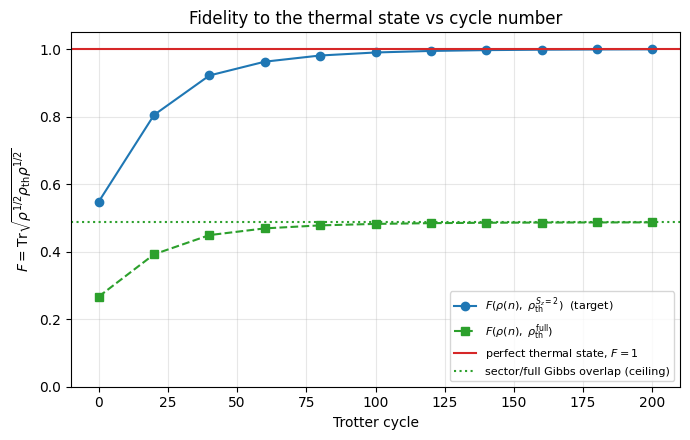

In [23]:
# ============================================================
#  CONTROL PANEL -- set everything for this run in one place
# ============================================================
# Physics
L      = 4             # fermion sites = system qubits
a_lat  = 1.0           # lattice spacing
m_mass = 0.5           # fermion mass
e_coup = 0.71          # gauge coupling
T      = 5.0           # bath temperature, sets both L(n) and the target Gibbs state

# Environment correlator D(x)
D_kind  = "delta"      # "delta" | "gaussian" | "const"
D0      = 1.0          # overall coupling strength
D_sigma = 1.0          # correlation length (only used when D_kind == "gaussian")

# Trotter / evolution
dt          = 0.1      # Trotter time step
cycle_start = 0        # first cycle count to sample
cycle_stop  = 200      # last cycle count (inclusive)
cycle_step  = 20       # spacing between sampled cycle counts

# Initial system state (bitstring; rightmost char is qubit 0)
init_state = "0001"
# ============================================================
# NOTE: cost grows with cycle_stop -- the circuit is evolved once out to the largest
# cycle count, saving rho along the way. Raise cycle_stop to confirm the plateau.

cycle_list = list(range(cycle_start, cycle_stop + 1, cycle_step))

H = get_schwinger_hamiltonian(L, m_mass, e_coup, a_lat)
n_sys = H.num_qubits

# Rebuild the dissipator for the chosen correlator D. For non-delta correlations
# diagonalized_lindblad_ops handles the off-diagonal D[n1,n2] terms.
D = D_matrix(L, a_lat, kind=D_kind, D0=D0,
             sigma=(D_sigma if D_kind == "gaussian" else None))
raw_L_ops = [L_n(n=n, H=H, L=L, a=a_lat, T=T) for n in range(L)]
eff_L_ops = diagonalized_lindblad_ops(raw_L_ops, D, a_lat)

# --- Theoretical thermal states to compare against ---
rho_sector, Q0 = gibbs_dm(H, T, sector_of=init_state)   # reachable target
rho_full, _    = gibbs_dm(H, T)                         # full Hilbert space

# --- Track F(rho(n), rho_th) vs cycle number ---
one_step = build_single_ancilla_circuit(H_op=H, eff_L_ops=eff_L_ops, n_sys=n_sys,
                                        dt=dt, n_steps=1)
rhos = rho_vs_cycles(one_step, n_sys, cycle_list, init_state)
F_sector = np.array([uhlmann_fidelity(r, rho_sector) for r in rhos])
F_full   = np.array([uhlmann_fidelity(r, rho_full)   for r in rhos])

# Ceiling on the full-Gibbs curve: even a PERFECT sector thermal state only overlaps
# the full Gibbs state this much, because it lives entirely in one charge sector.
F_ceiling = uhlmann_fidelity(rho_sector, rho_full)

print(f"final F vs Gibbs, Sz={Q0} sector (cycle {cycle_list[-1]}) : {F_sector[-1]:.5f}   <- circuit target")
print(f"final F vs Gibbs, full Hilbert space              : {F_full[-1]:.5f}")
print(f"ceiling F(sector Gibbs, full Gibbs)               : {F_ceiling:.5f}")

# --- Plot ---
plt.figure(figsize=(7, 4.5))
plt.plot(cycle_list, F_sector, "o-",
         label=fr"$F(\rho(n),\ \rho_\mathrm{{th}}^{{S_z={Q0}}})$  (target)")
plt.plot(cycle_list, F_full, "s--", color="tab:green",
         label=r"$F(\rho(n),\ \rho_\mathrm{th}^\mathrm{full})$")
plt.axhline(1.0, ls="-", color="tab:red", label="perfect thermal state, $F=1$")
plt.axhline(F_ceiling, ls=":", color="tab:green",
            label="sector/full Gibbs overlap (ceiling)")
plt.xlabel("Trotter cycle")
plt.ylabel(r"$F = \mathrm{Tr}\sqrt{\rho^{1/2}\rho_\mathrm{th}\rho^{1/2}}$")
plt.title("Fidelity to the thermal state vs cycle number")
plt.ylim(0, 1.05)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Two-qubit Gate Analysis
Where are these two-qubit gates coming from?

Every two-qubit gate in a Trotter step traces back to one Pauli term, in either $H$ or one of the dilation blocks $J_k$. Synthesizing $\exp(-i\theta P)$ for a Pauli string $P$ of **weight** $w$ (its number of non-identity factors) costs a CNOT ladder down and back around a single $R_z$:

$$\mathrm{CNOTs}\big(e^{-i\theta P}\big) = 2(w-1), \qquad w \geq 2,$$

with weight-1 and weight-0 terms free (a single-qubit rotation and a global phase). So the entire cost model is: **list the Pauli terms and histogram their weights.** The cells below do that for each physical piece separately, and check the prediction against an actual transpilation.

**Counting against a hardware ISA, not against the simulator.** `AerSimulator`'s basis includes `rzz`, `rxx` and `ryy`, so transpiling to *it* reports a single "two-qubit gate" where hardware needs two CNOTs — it hides exactly the cost we are trying to measure. We therefore count `cx` after transpiling to a generic superconducting ISA (`cx, rz, sx, x`). The split is exact and additive: the pieces sum to the measured whole-step count, which the cells assert.

In [24]:
# ---- two-qubit gate accounting helpers -------------------------------------
# Count CNOTs against a generic hardware ISA -- NOT the AerSimulator basis, which
# contains rzz/rxx/ryy: there exp(-i.theta.XX) transpiles to ONE 2q instruction and
# the real cost (2 CNOTs) vanishes from the count.
ISA_BASIS = ["cx", "rz", "sx", "x"]
pm_isa = generate_preset_pass_manager(basis_gates=ISA_BASIS, optimization_level=0)


def pauli_weights(op: SparsePauliOp, atol: float = 1e-12) -> dict[int, int]:
    """Histogram {weight: number of Pauli terms} of a SparsePauliOp.

    Weight = number of non-identity factors in the Pauli string. Terms whose
    coefficient simplified to ~0 are skipped."""
    out: dict[int, int] = {}
    for p, c in zip(op.paulis, op.coeffs):
        if abs(c) <= atol:
            continue
        w = int(np.count_nonzero(p.x | p.z))
        out[w] = out.get(w, 0) + 1
    return dict(sorted(out.items()))


def cx_model(op: SparsePauliOp, atol: float = 1e-12) -> int:
    """Predicted CNOTs for ONE LieTrotter rep of exp(-i op t).

    Each Pauli term of weight w becomes a CNOT ladder down and back around one rz:
    2(w-1) CNOTs, and nothing at all for w <= 1. Independent of the evolution time,
    so this is a purely structural count."""
    return sum(n * 2 * (w - 1) for w, n in pauli_weights(op, atol).items() if w >= 2)


def cx_transpiled(op: SparsePauliOp, time: float, reps: int = 1) -> int:
    """Actual CNOTs after synthesizing exp(-i op time) and transpiling to ISA_BASIS."""
    qc = QuantumCircuit(op.num_qubits)
    qc.append(PauliEvolutionGate(op, time=time, synthesis=LieTrotter(reps=reps)),
              range(op.num_qubits))
    return pm_isa.run(qc).count_ops().get("cx", 0)


def schwinger_hamiltonian_parts(L: int, m: float, e: float, a: float,
                                include_shifts: bool = True) -> dict:
    """The same terms get_schwinger_hamiltonian builds, kept as three separate pieces.

    Returns {"H_kin", "H_mass", "H_elec"}. They sum back to H exactly (asserted in
    the next cell), so any cost attributed to a piece is a real share of the total."""
    kin, mass, elec = [], [], []

    kin_coeff = 1.0 / (4.0 * a)
    for i in range(L - 1):
        kin.append(("XX", [i, i + 1], kin_coeff))
        kin.append(("YY", [i, i + 1], kin_coeff))

    for i in range(L):
        coeff = m * ((-1) ** i) / (2.0 * a)
        mass.append(("Z", [i], coeff))
        if include_shifts:
            mass.append(("I", [0], coeff))

    base_I = (a / 2.0) * (e ** 2 / 4.0)
    zz_coeff = (a * e ** 2) / 4.0
    for i in range(1, L + 1):
        C = i % 2
        if include_shifts:
            elec.append(("I", [0], base_I * (i + C)))
        if C == 1:
            for j in range(i):
                elec.append(("Z", [j], zz_coeff))
        for j in range(i):
            for k in range(j + 1, i):
                elec.append(("ZZ", [j, k], zz_coeff))

    mk = lambda terms: SparsePauliOp.from_sparse_list(terms, num_qubits=L).simplify()
    return {"H_kin": mk(kin), "H_mass": mk(mass), "H_elec": mk(elec)}


def lindblad_split(H_op: SparsePauliOp, L: int, a: float, T: float):
    """Split every L(n) = O(n) - (1/4T)[H, O(n)] into its two pieces.

    Returns (full, bare_O, commutator), each a list over sites n. The whole chain
    L(n) -> effective jumps -> J_k is LINEAR in the jump operator, so pushing the two
    pieces through it separately attributes the dilation-block cost between them."""
    Os = [O_n(n, L, a) for n in range(L)]
    comm = [(-(1.0 / (4.0 * T)) * (H_op @ O - O @ H_op)).simplify() for O in Os]
    full = [(O + c).simplify() for O, c in zip(Os, comm)]
    return full, Os, comm

In [25]:
# ---- Breakdown of the two-qubit gates in ONE Trotter step ------------------
L      = 4
a_lat  = 1.0
m_mass = 0.5
e_coup = 0.71
T      = 5.0
dt     = 0.1
D_kind, D0, D_sigma = "delta", 1.0, 1.0

H = get_schwinger_hamiltonian(L, m_mass, e_coup, a_lat)
n_sys = H.num_qubits
parts = schwinger_hamiltonian_parts(L, m_mass, e_coup, a_lat)
assert np.allclose(sum(parts.values()).simplify().to_matrix(), H.to_matrix()), \
    "H_kin + H_mass + H_elec must reproduce H exactly"

# --- 1. the coherent part, exp(-i H dt) -------------------------------------
print("=" * 76)
print("1. Hamiltonian evolution   exp(-i H dt)")
print("=" * 76)
print(f"{'term':9s}{'Pauli weights {w: count}':30s}{'CNOTs':>7}{'transpiled':>12}")
for name, op in parts.items():
    print(f"{name:9s}{str(pauli_weights(op)):30s}{cx_model(op):>7}"
          f"{cx_transpiled(op, dt):>12}")
cx_H = cx_model(H)
print(f"{'H total':9s}{str(pauli_weights(H)):30s}{cx_H:>7}{cx_transpiled(H, dt):>12}")
print("  H_mass is free: every one of its terms is a single Z (weight 1).")

# --- 2. which part of H reaches the jump operators at all -------------------
print()
print("=" * 76)
print("2. What survives into  L(n) = O(n) - (1/4T)[H, O(n)] ?")
print("=" * 76)
for name, op in parts.items():
    nrm = max(float(np.abs((op @ O_n(n, L, a_lat)
                            - O_n(n, L, a_lat) @ op).simplify().coeffs).sum())
              for n in range(L))
    verdict = "commutes -> contributes NOTHING" if nrm < 1e-12 else "drives the correction"
    print(f"  max_n ||[{name}, O(n)]||_1 = {nrm:.2e}   {verdict}")
print("  O(n) ~ Z_n, and H_mass / H_elec are built only from Z and ZZ, so all three")
print("  are diagonal in the same basis. The entire commutator IS the hopping term.")

# --- 3. the dilation blocks, exp(-i J_k sqrt(dt)) ---------------------------
raw_full, raw_O, raw_comm = lindblad_split(H, L, a_lat, T)
assert all(np.allclose(x.to_matrix(), L_n(n=n, H=H, L=L, a=a_lat, T=T).to_matrix())
           for n, x in enumerate(raw_full)), "split must reproduce L_n"

D = D_matrix(L, a_lat, kind=D_kind, D0=D0,
             sigma=(D_sigma if D_kind == "gaussian" else None))
eff_full = diagonalized_lindblad_ops(raw_full, D, a_lat)
eff_O    = diagonalized_lindblad_ops(raw_O,    D, a_lat)
eff_comm = diagonalized_lindblad_ops(raw_comm, D, a_lat)

print()
print("=" * 76)
print("3. Dilation blocks   exp(-i J_k sqrt(dt)),   J_k = |1><0| (x) L_k + h.c.")
print("=" * 76)
print(f"{'block':7s}{'L_k weights':22s}{'J_k weights':24s}{'CNOTs':>7}{'transp':>8}"
      f"{'from O':>8}{'from [H,O]':>12}")
cx_blocks = cx_from_O = cx_from_comm = ancilla_tax = 0
for k, (Lf, Lo, Lc) in enumerate(zip(eff_full, eff_O, eff_comm), start=1):
    Jf = build_J_operator([Lf], n_sys=n_sys)
    Jo = build_J_operator([Lo], n_sys=n_sys)
    Jc = build_J_operator([Lc], n_sys=n_sys)
    print(f"{'J_' + str(k):7s}{str(pauli_weights(Lf)):22s}{str(pauli_weights(Jf)):24s}"
          f"{cx_model(Jf):>7}{cx_transpiled(Jf, np.sqrt(dt)):>8}"
          f"{cx_model(Jo):>8}{cx_model(Jc):>12}")
    cx_blocks     += cx_model(Jf)
    cx_from_O     += cx_model(Jo)
    cx_from_comm  += cx_model(Jc)
    ancilla_tax   += cx_model(Jf) - cx_model(Lf)
print(f"{'total':53s}{cx_blocks:>7}{'':8}{cx_from_O:>8}{cx_from_comm:>12}")

mix = cx_blocks - (cx_from_O + cx_from_comm)
if mix:
    print(f"  (!) {mix} CNOTs are not attributable: the two pieces share Pauli strings")
    print("      and partially cancel under simplify(); treat the split as approximate.")
print(f"  Dilating onto the ancilla lifts EVERY Pauli term of L_k by one qubit")
print(f"  (weight w -> w+1, so +2 CNOTs per term): {ancilla_tax} of these {cx_blocks}")
print(f"  CNOTs are that ancilla leg alone.")

# --- 4. the whole step ------------------------------------------------------
step = build_single_ancilla_circuit(H_op=H, eff_L_ops=eff_full, n_sys=n_sys,
                                    dt=dt, n_steps=1)
cx_step = pm_isa.run(step).count_ops().get("cx", 0)

sources = {
    "[H_kin, O(n)] inside J_k":    cx_from_comm,
    "H_elec (ZZ) in exp(-iH dt)":  cx_model(parts["H_elec"]),
    "H_kin (XX+YY) in exp(-iH dt)": cx_model(parts["H_kin"]),
    "bare O(n) inside J_k":        cx_from_O,
    "H_mass (Z) in exp(-iH dt)":   cx_model(parts["H_mass"]),
}
print()
print("=" * 76)
print(f"4. One Trotter step: {cx_step} CNOTs measured, {cx_H + cx_blocks} predicted")
print("=" * 76)
for name, v in sorted(sources.items(), key=lambda kv: -kv[1]):
    print(f"  {name:32s}{v:>5}{100 * v / cx_step:>8.1f}%")
assert cx_step == cx_H + cx_blocks, "per-block prediction must match the built circuit"

kin_direct = cx_model(parts["H_kin"])
kin_total = kin_direct + cx_from_comm
print(f"\n  The hopping term XX+YY drives {kin_total}/{cx_step} = "
      f"{100 * kin_total / cx_step:.0f}% of the step:")
print(f"    {kin_direct:>4} directly, in exp(-iH dt)")
print(f"    {cx_from_comm:>4} indirectly, through [H, O(n)] inside the jump operators")

1. Hamiltonian evolution   exp(-i H dt)
term     Pauli weights {w: count}        CNOTs  transpiled
H_kin    {2: 6}                             12          12
H_mass   {1: 4}                              0           0
H_elec   {0: 1, 1: 3, 2: 6}                 12          12
H total  {0: 1, 1: 4, 2: 12}                24          24
  H_mass is free: every one of its terms is a single Z (weight 1).

2. What survives into  L(n) = O(n) - (1/4T)[H, O(n)] ?
  max_n ||[H_kin, O(n)]||_1 = 1.00e+00   drives the correction
  max_n ||[H_mass, O(n)]||_1 = 0.00e+00   commutes -> contributes NOTHING
  max_n ||[H_elec, O(n)]||_1 = 0.00e+00   commutes -> contributes NOTHING
  O(n) ~ Z_n, and H_mass / H_elec are built only from Z and ZZ, so all three
  are diagonal in the same basis. The entire commutator IS the hopping term.

3. Dilation blocks   exp(-i J_k sqrt(dt)),   J_k = |1><0| (x) L_k + h.c.
block  L_k weights           J_k weights               CNOTs  transp  from O  from [H,O]
J_1    {0: 1, 

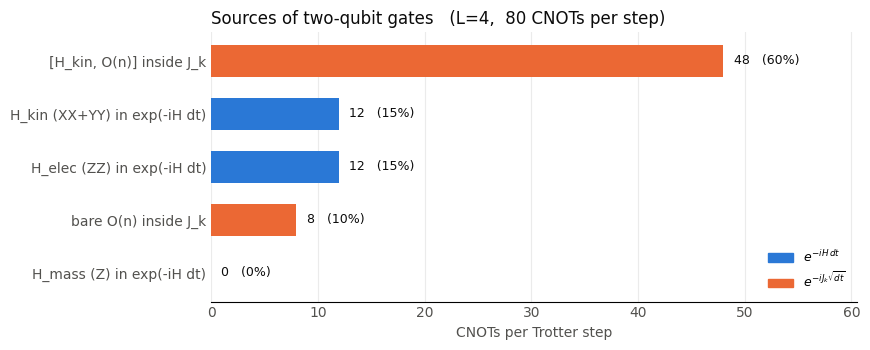

In [26]:
# ---- Chart: where the CNOTs come from --------------------------------------
# Categorical hues in fixed slot order; colour = which block of the step the cost
# sits in. Every bar is directly labelled, so identity is never colour-alone.
C_H, C_J = "#2a78d6", "#eb6834"          # slot 1 blue, slot 2 orange
INK, INK2 = "#0b0b0b", "#52514e"

block_of = {
    "[H_kin, O(n)] inside J_k":     "J",
    "bare O(n) inside J_k":         "J",
    "H_kin (XX+YY) in exp(-iH dt)": "H",
    "H_elec (ZZ) in exp(-iH dt)":   "H",
    "H_mass (Z) in exp(-iH dt)":    "H",
}

items = sorted(sources.items(), key=lambda kv: kv[1])      # ascending -> biggest on top
labels = [k for k, _ in items]
vals = [v for _, v in items]

fig, ax = plt.subplots(figsize=(8.8, 3.6))
ax.barh(labels, vals, height=0.62,
        color=[C_H if block_of[k] == "H" else C_J for k in labels])
for y, v in enumerate(vals):
    ax.text(v + max(vals) * 0.02, y, f"{v}   ({100 * v / cx_step:.0f}%)",
            va="center", fontsize=9, color=INK)

ax.set_xlim(0, max(vals) * 1.26)
ax.set_xlabel("CNOTs per Trotter step", color=INK2)
ax.set_title(f"Sources of two-qubit gates   (L={L},  {cx_step} CNOTs per step)",
             color=INK, loc="left")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=C_H),
                   plt.Rectangle((0, 0), 1, 1, color=C_J)],
          labels=[r"$e^{-iH\,dt}$", r"$e^{-iJ_k\sqrt{dt}}$"],
          frameon=False, loc="lower right", fontsize=9)
ax.xaxis.grid(True, alpha=0.25, lw=0.8)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors=INK2, length=0)
plt.tight_layout()
plt.show()

## Fixing $e$ and $m$, increasing $L$
How does relaxation time depend on L? This treats the Schwinger model as a generic lattice model, typical for condensed matter physics

### What "relaxation time" means here

The question this section answers is the operational one: **starting from the state
the protocol actually starts from, how long until it is thermal?**

That is a property of the dynamics *and* of the initial state, and it only becomes a
number once "thermal enough" is pinned down. The protocol always starts from the
staggered state $|0101\ldots\rangle$, so the sweep below runs exactly that state and
records two distances along the one trajectory:

$$
D(t) \;=\; \frac{\bigl\|\rho(t)-\rho_\mathrm{ss}\bigr\|_1}
                {\bigl\|\rho(0)-\rho_\mathrm{ss}\bigr\|_1},
\qquad\qquad
F(t) \;=\; F\!\left(\rho(t),\,\rho_\mathrm{th}^{S_z=0}\right).
$$

$D$ is the trace distance to the fixed point, normalised so $D(0)=1$ — read it as
"what fraction of the journey is left". It gives

$$
t_{50},\; t_{90},\; t_{99}: \quad\text{first time } D \le 0.5,\ 0.1,\ 0.01
\ \text{ and stays there,}
$$

i.e. 50%, 90%, 99% relaxed. $F$ is the Uhlmann fidelity to the sector Gibbs state,
the convergence criterion the rest of this notebook uses, and it gives
$t_{F\geq0.9}$ and $t_{F\geq0.99}$.

Neither distance is the "right" one — they ask *how far from the fixed point* and
*how good is the thermal state*, and they disagree by a lot on the same trajectory.
Both are reported so the choice is explicit. Whichever threshold matches the accuracy
you actually want is the one that sets the run length:

$$
n_\mathrm{cycles} \;\approx\; t_\mathrm{threshold}\,/\,dt .
$$

**Note on what is deliberately *not* measured.** The thermal-state section above
suggests budgeting $n_\mathrm{steps}\approx(\text{a few})\,\tau/dt$ with
$\tau=1/|\mathrm{Re}\,\lambda_\mathrm{gap}|$ from the Liouvillian spectrum. That is
the decay constant of the slowest *mode*, and it bounds the wait only if the initial
state actually excites that mode appreciably. This section measures the state instead
of the spectrum, so no eigenvalue of the Liouvillian is computed anywhere below.

**Why this is tractable.** $H$ and every $L(n)$ commute with the total charge, so the
dynamics never leaves the initial state's sector and the density matrix to evolve is
$d_\mathrm{sec}\times d_\mathrm{sec}$ with $d_\mathrm{sec}=\binom{L}{L/2}$, not
$2^L\times2^L$ — $252\times252$ instead of $1024\times1024$ at $L=10$. The Lindblad
equation is integrated on that block with RK4, using only sparse products against a
dense $\rho$; the $d_\mathrm{sec}^2\times d_\mathrm{sec}^2$ superoperator is never
formed. The restriction is validated against the full $4^L$ Liouvillian below.

In [27]:
# ============================================================
#  The model, restricted to a charge sector
# ============================================================
# H and every L(n) commute with the total charge Sz = sum_n Z_n, so the dynamics
# never leaves the initial state's sector (the point made in the thermal-state
# section above). The density matrix that has to be evolved is therefore
# d_sec x d_sec with d_sec = C(L, L/2), not 2^L x 2^L:
#
#     L        2     4     6     8    10    12
#     2^L      4    16    64   256  1024  4096
#     d_sec    2     6    20    70   252   924
#
# At L = 10 that is a 252 x 252 rho instead of 1024 x 1024, with sparse operators
# acting on it. Restricting to the sector is what lets this sweep reach past the
# few sites where the full Hilbert space is affordable.

def sector_indices(L: int, Q0: int = 0) -> np.ndarray:
    """Computational-basis indices with total charge Sz = (#0) - (#1) = Q0."""
    return np.array([i for i in range(2 ** L)
                     if L - 2 * bin(i).count("1") == Q0], dtype=int)


def sector_ops(L, m, e, a, T, D_kind="delta", D0=1.0, D_sigma=None, Q0=0):
    """(H, effective jump operators) at size L, restricted to the Sz = Q0 block.

    Exactly the construction used everywhere else in this notebook --
    get_schwinger_hamiltonian -> L_n -> D_matrix -> diagonalized_lindblad_ops --
    with the rows and columns outside the sector dropped at the very end. That
    truncation is lossless here precisely because H and the L(n) are block
    diagonal in Sz, which the validation cell below checks against the full
    4^L Liouvillian.

    Returns (H_sec, [L_sec], idx) as scipy CSR matrices plus the index list that
    maps sector positions back to full-Hilbert basis states.
    """
    H = get_schwinger_hamiltonian(L, m, e, a)
    raw = [L_n(n=n, H=H, L=L, a=a, T=T) for n in range(L)]
    D = D_matrix(L, a, kind=D_kind, D0=D0, sigma=D_sigma)
    eff = diagonalized_lindblad_ops(raw, D, a)

    idx = sector_indices(L, Q0)
    cut = lambda op: op.to_matrix(sparse=True).tocsr()[idx][:, idx].tocsr()
    return cut(H), [cut(x) for x in eff], idx

In [28]:
# ============================================================
#  How long does the staggered state take to thermalize?
# ============================================================
# The Lindblad equation is integrated directly on the d_sec x d_sec density matrix
# with RK4 -- no superoperator, no eigenvalues. relaxation_curve does all the work:
# it runs the one trajectory that starts from |0101...> and records how far it still
# is from the fixed point, in two different distances, so a threshold can be turned
# into a time.

def staggered_bitstring(L: int) -> str:
    """|0101...>, the half-filling reference state (Sz = 0). Rightmost char = qubit 0."""
    return "01" * (L // 2) if L % 2 == 0 else "0" + "10" * (L // 2)


def gibbs_sector(H_sec, T):
    """e^{-H/T}/Z built directly in the sector -- the target the dynamics can reach.

    Same object as gibbs_dm(H, T, sector_of=...) above, minus the embedding back
    into the full 2^L space, so it can be compared with the sector density matrices
    this section evolves."""
    ev, U = np.linalg.eigh(H_sec.toarray() if sp.issparse(H_sec) else H_sec)
    w = np.exp(-(ev - ev.min()) / T)
    return (U * (w / w.sum())) @ U.conj().T


def lindblad_rhs(H_sec, L_sec):
    """Closure evaluating drho/dt = -i[H, rho] + sum_k (L_k rho L_k^dag - {L_k^dag L_k, rho}/2).

    Written with the non-Hermitian effective Hamiltonian

        K = -i H - (1/2) sum_k L_k^dag L_k     ->     drho/dt = K rho + rho K^dag
                                                                + sum_k L_k rho L_k^dag,

    which folds the whole anticommutator into one matrix and halves the number of
    products (2 + 2m instead of 2 + 4m). Sparse operators against a dense rho, so
    each product costs nnz * d_sec and the right-hand side stays cheap with d_sec
    in the hundreds. This is the only place the generator is ever applied, and it
    is applied to a state -- never assembled as a d_sec^2 x d_sec^2 matrix."""
    Ldag = [Lk.conj().T.tocsr() for Lk in L_sec]
    K = (-1j * H_sec - 0.5 * sum(Ld @ Lk for Ld, Lk in zip(Ldag, L_sec))).tocsr()
    Kdag = K.conj().T.tocsr()

    def rhs(rho):
        out = K @ rho + rho @ Kdag
        for Lk, Ld in zip(L_sec, Ldag):
            out = out + Lk @ rho @ Ld
        return out
    return rhs


def rk4_dt(H_sec, safety=0.9):
    """Explicit-RK4 step size. The generator's fastest scale is set by ||H||, so
    scale dt with it; the electric term grows with L, hence so must the step shrink."""
    return safety / max(float(spla.norm(H_sec, np.inf)), 1.0)


def _rk4_stepper(rhs, dt):
    def step(rho):
        k1 = rhs(rho)
        k2 = rhs(rho + 0.5 * dt * k1)
        k3 = rhs(rho + 0.5 * dt * k2)
        k4 = rhs(rho + dt * k3)
        return rho + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return step


def basis_rho(init_state, idx, d):
    """|s><s| as a d_sec x d_sec matrix, given the sector's index list."""
    full = int(init_state, 2) if isinstance(init_state, str) else int(init_state)
    hit = np.where(idx == full)[0]
    if hit.size == 0:
        raise ValueError(f"{init_state!r} does not lie in this charge sector.")
    rho0 = np.zeros((d, d), dtype=complex)
    rho0[int(hit[0]), int(hit[0])] = 1.0
    return rho0


def relaxation_curve(H_sec, L_sec, init_state, idx, T, dt=None, t_cap=4000.0,
                     sample_dt=0.25, D_floor=1e-3):
    """Distance-to-thermal vs time, starting from a computational basis state.

    Two passes over the same trajectory. The first runs coarsely until rho stops
    moving and keeps that as rho_ss -- the fixed point has to be *found*, since the
    high-temperature construction only makes the Gibbs state stationary
    approximately (see the validation cell). The second replays the trajectory on a
    fine grid recording both distances:

        D(t) = ||rho(t) - rho_ss||_1 / ||rho(0) - rho_ss||_1      (D(0) = 1)
        F(t) = F(rho(t), sector Gibbs)

    Two passes rather than one pass keeping every snapshot, because storing the
    trajectory costs d_sec^2 per sample and that is what blows up with L.

    `sample_dt` is the spacing of the recorded points, and therefore the resolution
    of every threshold time read off them. `D_floor` is how deep the curve has to be
    trustworthy: pass 2 stops there, and pass 1's stillness tolerance is set from it,
    so the default 1e-3 supports t_99 with a decade of headroom while keeping the
    cost down. Lower it to see further down the tail, at proportionate cost.

    Returns (ts, D, F, rho_ss, dt).
    """
    d = H_sec.shape[0]
    rho0 = basis_rho(init_state, idx, d)

    dt = rk4_dt(H_sec) if dt is None else dt
    step = _rk4_stepper(lindblad_rhs(H_sec, L_sec), dt)
    coarse = max(1, int(round(2.0 / dt)))          # pass 1: check every ~2 time units
    fine = max(1, int(round(sample_dt / dt)))      # pass 2: record every sample_dt
    ss_tol = 1e-3 * D_floor                        # rho_ss error ~ ss_tol * (decay time)

    rho, t, prev = rho0.copy(), 0.0, None
    while t < t_cap:
        for _ in range(coarse):
            rho = step(rho)
        t += coarse * dt
        if prev is not None and np.linalg.norm(rho - prev) < ss_tol:
            break
        prev = rho.copy()
    rho_ss, t_ss = rho, t

    tdist = lambda A, B: 0.5 * float(np.abs(np.linalg.eigvalsh(A - B)).sum())
    target = gibbs_sector(H_sec, T)
    D0 = tdist(rho0, rho_ss)
    rho, t = rho0.copy(), 0.0
    ts, Ds, Fs = [0.0], [1.0], [uhlmann_fidelity(rho0, target)]
    while t < t_ss:
        for _ in range(fine):
            rho = step(rho)
        t += fine * dt
        ts.append(t)
        Ds.append(tdist(rho, rho_ss) / D0)
        Fs.append(uhlmann_fidelity(rho, target))
        if Ds[-1] <= D_floor:
            break
    return np.array(ts), np.array(Ds), np.array(Fs), rho_ss, dt


def first_below(ts, ys, x):
    """First time y drops below x AND stays there (None if it never does)."""
    for k in range(len(ts)):
        if (ys[k:] <= x).all():
            return float(ts[k])
    return None


def first_above(ts, ys, x):
    """First time y rises above x AND stays there (None if it never does)."""
    for k in range(len(ts)):
        if (ys[k:] >= x).all():
            return float(ts[k])
    return None


# The thresholds this section reports. Both families are ORDERED (a stricter
# threshold is always a later time); they are kept separate because one measures
# distance to the fixed point and the other quality of the thermal state.
D_LEVELS = [("t_50", 0.50), ("t_90", 0.10), ("t_99", 0.01)]
F_LEVELS = [("t_F90", 0.90), ("t_F99", 0.99)]


def thermalization_times(ts, D, F):
    """{threshold name -> time} for every level in D_LEVELS and F_LEVELS."""
    out = {name: first_below(ts, D, x) for name, x in D_LEVELS}
    out.update({name: first_above(ts, F, x) for name, x in F_LEVELS})
    return out

In [29]:
# ---- Validating the machinery the sweep rests on ---------------------------
# Everything below is measured off an RK4 trajectory inside one charge sector, so
# three things have to be established first:
#   1. the sector trajectory IS the full-Hilbert-space trajectory, and
#   2. RK4 at the default step size is converged, and
#   3. rho_ss has to be found by evolving -- the Gibbs state is only approximately
#      stationary, so it cannot just be assumed to be the fixed point.
# All checkable at L = 4, where the full 4^L Liouvillian from earlier in the
# notebook still fits and can be exponentiated exactly.
from scipy.linalg import expm

L_chk, a_chk, m_chk, e_chk, T_chk, D0_chk = 4, 1.0, 0.5, 0.71, 5.0, 1.0

H_chk = get_schwinger_hamiltonian(L_chk, m_chk, e_chk, a_chk)
eff_chk = diagonalized_lindblad_ops(
    [L_n(n=n, H=H_chk, L=L_chk, a=a_chk, T=T_chk) for n in range(L_chk)],
    D_matrix(L_chk, a_chk, kind="delta", D0=D0_chk), a_chk)

# Full-space Liouvillian. Its D is the identity because the correlator is already
# folded into eff_chk. vec() is column-stacking, matching vec(A rho B) = (B^T (x) A) vec(rho).
Lfull = build_liouvillian(H_chk, eff_chk, np.eye(len(eff_chk)), a_chk).toarray()
d_full = 2 ** L_chk

H_chk_sec, L_chk_sec, idx_chk = sector_ops(L_chk, m_chk, e_chk, a_chk, T_chk,
                                           D_kind="delta", D0=D0_chk, Q0=0)
init_chk = staggered_bitstring(L_chk)
rho0_sec = basis_rho(init_chk, idx_chk, H_chk_sec.shape[0])
vec0 = np.zeros(d_full * d_full, dtype=complex)
vec0[int(init_chk, 2) * d_full + int(init_chk, 2)] = 1.0


def sector_to_full(r):
    """Embed a sector density matrix back into the full 2^L x 2^L space."""
    out = np.zeros((d_full, d_full), dtype=complex)
    out[np.ix_(idx_chk, idx_chk)] = r
    return out


def rk4_to(t_want, dt_target):
    """Sector rho at exactly t_want, using the largest step <= dt_target that divides it."""
    n = int(np.ceil(t_want / dt_target))
    step = _rk4_stepper(lindblad_rhs(H_chk_sec, L_chk_sec), t_want / n)
    r = rho0_sec.copy()
    for _ in range(n):
        r = step(r)
    return r, n


# --- 1 + 2: sector RK4 vs exact full-space exp(L t), as dt shrinks -----------
t_ref = 5.0
rho_exact = (expm(Lfull * t_ref) @ vec0).reshape(d_full, d_full, order="F")
leak = float(np.abs(rho_exact).sum()
             - np.abs(rho_exact[np.ix_(idx_chk, idx_chk)]).sum())
dt_default = rk4_dt(H_chk_sec)

print(f"Exact full-space evolution at L = {L_chk} (Liouvillian {d_full**2} x {d_full**2}), "
      f"t = {t_ref}:")
print(f"  weight that leaked out of the Sz = 0 sector : {leak:.1e}  "
      f"-> the block truncation is exact\n")
print(f"{'dt':>10}{'steps':>8}{'max|rho_RK4 - rho_exact|':>27}{'ratio':>9}")
prev = None
for fac in (1, 2, 4, 8):
    r, n = rk4_to(t_ref, dt_default / fac)
    err = float(np.abs(sector_to_full(r) - rho_exact).max())
    ratio = f"{prev / err:>9.1f}" if prev else f"{'--':>9}"
    print(f"{t_ref / n:>10.5f}{n:>8}{err:>27.2e}{ratio}")
    prev = err
print(f"\n  Error falls by ~16 per halving = 4th order, and it converges to ZERO, not")
print(f"  to a floor -- so the sector restriction introduces no error of its own and")
print(f"  the default dt = {dt_default:.4f} is worth ~{prev * 16:.0e} on rho at this size.")

# --- 3: is the Gibbs state actually the fixed point? ------------------------
print("\nIs rho_th the fixed point, or does rho_ss have to be found by evolving?")
print(f"{'L':>3}{'d_sec':>7}{'||Lindblad[rho_th]||':>23}{'||rho_ss - rho_th||_1':>24}")
for L in (2, 4, 6):
    H_s, L_s, ix = sector_ops(L, m_chk, e_chk, a_chk, T_chk, D_kind="delta", D0=D0_chk)
    rho_th = gibbs_sector(H_s, T_chk)
    resid = float(np.linalg.norm(lindblad_rhs(H_s, L_s)(rho_th)))
    _, _, _, rho_ss_L, _ = relaxation_curve(H_s, L_s, staggered_bitstring(L), ix, T_chk)
    tdist = 0.5 * float(np.abs(np.linalg.eigvalsh(rho_ss_L - rho_th)).sum())
    print(f"{L:>3}{H_s.shape[0]:>7}{resid:>23.2e}{tdist:>24.2e}")
print("  Nonzero: L(n) = O(n) - [H, O(n)]/4T is only detailed-balanced to leading")
print("  order in 1/T, so rho_th is a near-fixed-point, not the fixed point. Close")
print("  enough that F(rho_ss, rho_th) rounds to 1, far enough that D(t) would floor")
print("  around here if rho_th were substituted for rho_ss. Hence pass 1.")

# --- and why rho_ss is a per-sector object ----------------------------------
n_zero_full = int((np.abs(np.linalg.eigvals(Lfull)) < 1e-9).sum())
print(f"\nStationary states of the FULL Liouvillian at L = {L_chk}: {n_zero_full}"
      f" = one per charge sector (Sz = "
      f"{', '.join(str(L_chk - 2 * k) for k in range(L_chk + 1))}).")
print("  The full dynamics has no unique fixed point, so 'the' relaxation time is not")
print("  a property of the model -- it is a property of a sector plus a starting state.")
print(f"  Everything below is quoted for Sz = 0 starting from |{init_chk}>.")

Exact full-space evolution at L = 4 (Liouvillian 256 x 256), t = 5.0:
  weight that leaked out of the Sz = 0 sector : -2.2e-16  -> the block truncation is exact

        dt   steps   max|rho_RK4 - rho_exact|    ratio
   0.29412      17                   6.45e-05       --
   0.14706      34                   3.57e-06     18.1
   0.07463      67                   2.19e-07     16.3
   0.03731     134                   1.31e-08     16.8

  Error falls by ~16 per halving = 4th order, and it converges to ZERO, not
  to a floor -- so the sector restriction introduces no error of its own and
  the default dt = 0.2996 is worth ~2e-07 on rho at this size.

Is rho_th the fixed point, or does rho_ss have to be found by evolving?
  L  d_sec   ||Lindblad[rho_th]||   ||rho_ss - rho_th||_1
  2      2               4.77e-04                1.89e-04
  4      6               4.70e-04                2.29e-04
  6     20               3.29e-04                3.01e-04
  Nonzero: L(n) = O(n) - [H, O(n)]/4T is 

In [30]:
import time

# ============================================================
#  CONTROL PANEL -- thermalization time vs system size
# ============================================================
# e and m are FIXED; only L moves. Everything else about the model is held at the
# values used throughout this notebook, so the only thing the sweep varies is the
# number of fermion sites.
a_lat  = 1.0
m_mass = 0.5           # FIXED
e_coup = 0.71          # FIXED
T      = 5.0
D_kind, D0, D_sigma = "delta", 1.0, None
Q0 = 0                 # half filling: the sector the staggered state |0101...> lives in

L_list  = [2, 4, 6, 8, 10]
D_floor = 1e-3         # how deep the trace-distance curve is measured (supports t_99)
# ============================================================
# Cost: about 9 minutes, essentially all of it L = 10 -- drop that entry and the
# sweep runs in 20 seconds. L = 10 is affordable only because nothing here forms a
# superoperator: it is a 252 x 252 rho, not a 63504 x 63504 matrix. Cost goes as
# (RHS ~ d_sec^2 L) x (steps ~ t_end/dt), with dt shrinking like 1/||H|| and t_end
# growing with L, so L = 12 (d_sec = 924) is another factor of ~25 and impractical
# in a notebook.

relax = {}
hdr = ["L", "d_sec", "dt_RK4"] + [n for n, _ in D_LEVELS] + [n for n, _ in F_LEVELS]
print("".join(f"{h:>9}" for h in hdr)
      + f"{'t99/t90':>9}{'F(ss,th)':>10}{'sec':>7}")
print("-" * (9 * len(hdr) + 26))

for L in L_list:
    t_start = time.time()
    H_sec, L_sec, idx = sector_ops(L, m_mass, e_coup, a_lat, T,
                                   D_kind=D_kind, D0=D0, D_sigma=D_sigma, Q0=Q0)
    init = staggered_bitstring(L)

    # the one trajectory this whole section is about
    ts, Ds, Fs, rho_ss, dt_rk = relaxation_curve(H_sec, L_sec, init, idx, T,
                                                 D_floor=D_floor)
    tt = thermalization_times(ts, Ds, Fs)

    # does the fixed point still look like the sector Gibbs state at this L?
    F_ss = uhlmann_fidelity(rho_ss, gibbs_sector(H_sec, T))

    relax[L] = dict(d_sec=H_sec.shape[0], ts=ts, D=Ds, F=Fs, times=tt,
                    F_ss=F_ss, dt_rk=dt_rk, init=init, rho_ss=rho_ss,
                    secs=time.time() - t_start)

    cells = f"{L:>9}{H_sec.shape[0]:>9}{dt_rk:>9.4f}"
    for n, _ in D_LEVELS + F_LEVELS:
        cells += f"{tt[n]:>9.1f}" if tt[n] is not None else f"{'--':>9}"
    print(cells + f"{tt['t_99'] / tt['t_90']:>9.2f}{F_ss:>10.6f}"
          f"{relax[L]['secs']:>7.0f}")

# --- what the table says, in words -------------------------------------------
Ls_done = [L for L in L_list if L in relax]
g_ = lambda k: np.array([relax[L]["times"][k] for L in Ls_done], dtype=float)
lo, hi = Ls_done[0], Ls_done[-1]
print(f"\n  From L = {lo} to L = {hi}, thermalization slows by "
      + ",  ".join(f"{k}: x{g_(k)[-1] / g_(k)[0]:.1f}"
                   for k, _ in D_LEVELS + F_LEVELS) + ".")
print(f"  At L = {hi} the thresholds span a factor of "
      f"{max(g_(k)[-1] for k, _ in D_LEVELS + F_LEVELS) / min(g_(k)[-1] for k, _ in D_LEVELS + F_LEVELS):.0f}"
      f" -- 'thermalized' is not one number, so pick the threshold, then read the time.")
print(f"  Sampling resolution is sample_dt = 0.25, so every time above is good to "
      f"+/- 0.25.")
print(f"  Fixed point vs sector Gibbs state: F >= "
      f"{min(relax[L]['F_ss'] for L in Ls_done):.6f} across the sweep -- the "
      f"high-T\n  construction still lands on the thermal state at every size here.")

        L    d_sec   dt_RK4     t_50     t_90     t_99    t_F90    t_F99  t99/t90  F(ss,th)    sec
--------------------------------------------------------------------------------------------------
        2        2   0.7188      2.2      7.2     13.7      1.4      3.6     1.90  1.000000      0
        4        6   0.2996      1.8      8.7     22.2      2.1      7.2     2.55  1.000000      1
        6       20   0.1892      2.1     12.7     39.7      3.4     11.2     3.13  1.000000      4
        8       70   0.1383      2.8     16.6     60.3      5.0     16.3     3.63  1.000000     30
       10      252   0.1054      3.6     21.5     81.6      6.3     21.9     3.79  1.000000    506

  From L = 2 to L = 10, thermalization slows by t_50: x1.7,  t_90: x3.0,  t_99: x6.0,  t_F90: x4.4,  t_F99: x6.1.
  At L = 10 the thresholds span a factor of 23 -- 'thermalized' is not one number, so pick the threshold, then read the time.
  Sampling resolution is sample_dt = 0.25, so every time above is 

   threshold   power-law p     R^2   exp rate c     R^2   better
        t_50          0.30  0.4836        0.072  0.7068   no clear trend
        t_90          0.68  0.9275        0.142  0.9923   exponential
        t_99          1.13  0.9724        0.229  0.9877   exponential
       t_F90          0.94  0.9655        0.191  0.9885   exponential
       t_F99          1.12  0.9957        0.222  0.9724   power law

  Only 5 sizes, all small, so read the exponents as a trend and not
  as an asymptotic law -- the two forms are hard to separate over one decade of L.
  t_50 barely move with L at all (R^2 < 0.8); the exponent
  printed for them is fitting noise. The early relaxation is size independent
  -- it is the TAIL that slows down as L grows.


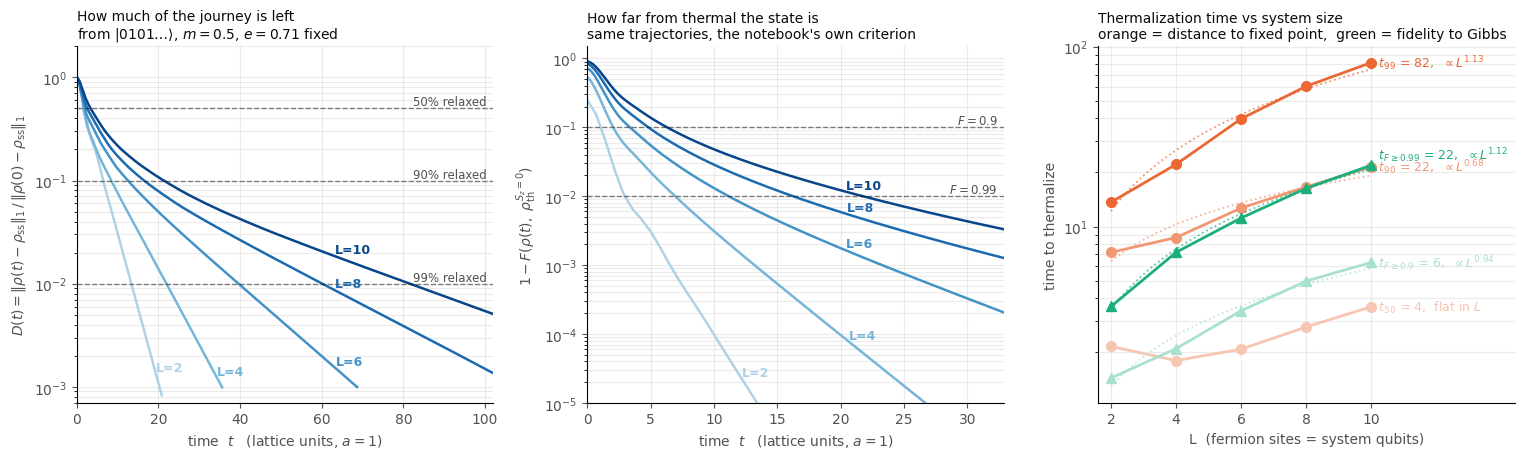

In [31]:
# ---- How thermalization time grows with L -----------------------------------
# Two ordered quantities, so two sequential ramps and no categorical hues for
# levels: L gets a blue ramp (light = small L), and each family of thresholds gets
# its own hue ramped by strictness (light = loose, dark = strict). The two FAMILIES
# are different quantities -- distance to the fixed point vs quality of the thermal
# state -- so they get different hues. Everything is directly labelled; colour is
# never the only channel carrying identity.
INK, INK2 = "#0b0b0b", "#52514e"
C_D, C_F = "#eb6834", "#1baf7a"        # trace-distance family, fidelity family

Ls_done = [L for L in L_list if L in relax]
_lo, _hi = min(Ls_done), max(Ls_done)
shade = lambda L: plt.cm.Blues(0.32 + 0.60 * ((L - _lo) / (_hi - _lo)
                                              if _hi > _lo else 1.0))
ramp = lambda base, k, n: tuple(
    c + (1 - c) * (0.62 * (1 - k / max(n - 1, 1)))          # k=0 lightest
    for c in tuple(int(base[i:i + 2], 16) / 255 for i in (1, 3, 5)))

Larr = np.array(Ls_done, dtype=float)
series = ([(n, x, ramp(C_D, k, len(D_LEVELS)), "o")
           for k, (n, x) in enumerate(D_LEVELS)]
          + [(n, x, ramp(C_F, k, len(F_LEVELS)), "^")
             for k, (n, x) in enumerate(F_LEVELS)])
vals = {n: np.array([relax[L]["times"][n] for L in Ls_done], dtype=float)
        for n, _, _, _ in series}
label = {"t_50": r"$t_{50}$", "t_90": r"$t_{90}$", "t_99": r"$t_{99}$",
         "t_F90": r"$t_{F\geq0.9}$", "t_F99": r"$t_{F\geq0.99}$"}


def fit_scaling(x, y):
    """Fit y = A x^p and y = A e^{cx}; return both with their log-space R^2."""
    ly = np.log(y)
    out = {}
    for name, xv in (("power", np.log(x)), ("exponential", x)):
        s, i = np.polyfit(xv, ly, 1)
        ss_res = float(((ly - (s * xv + i)) ** 2).sum())
        ss_tot = float(((ly - ly.mean()) ** 2).sum())
        out[name] = (s, np.exp(i), 1 - ss_res / ss_tot)
    return out


fits = {n: fit_scaling(Larr, vals[n]) for n, _, _, _ in series}
R2_MIN = 0.80          # below this, neither form describes the series -- say so
print(f"{'threshold':>12}{'power-law p':>14}{'R^2':>8}{'exp rate c':>13}{'R^2':>8}   better")
for n, _, _, _ in series:
    p, _, r2p = fits[n]["power"]
    c, _, r2e = fits[n]["exponential"]
    verdict = ("no clear trend" if max(r2p, r2e) < R2_MIN
               else "exponential" if r2e > r2p else "power law")
    print(f"{n:>12}{p:>14.2f}{r2p:>8.4f}{c:>13.3f}{r2e:>8.4f}   {verdict}")
print(f"\n  Only {len(Ls_done)} sizes, all small, so read the exponents as a trend and not")
print("  as an asymptotic law -- the two forms are hard to separate over one decade of L.")
flat = [n for n, _, _, _ in series if max(fits[n]["power"][2],
                                          fits[n]["exponential"][2]) < R2_MIN]
if flat:
    print(f"  {', '.join(flat)} barely move with L at all (R^2 < {R2_MIN}); the exponent")
    print("  printed for them is fitting noise. The early relaxation is size independent")
    print("  -- it is the TAIL that slows down as L grows.")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15.5, 4.7))


def label_curve(ax, L, ts, ys, x_at, y_floor):
    """Put "L=n" on a curve at time x_at, wherever that lands vertically.

    Anchored by TIME rather than by array position, because the trajectories have
    very different lengths and a fixed fraction of the array falls off the axes for
    the large sizes. If the curve has already dropped below the visible y range by
    x_at -- as the small sizes have -- back up to the last point still on screen."""
    k = int(np.clip(np.searchsorted(ts, x_at), 0, len(ts) - 1))
    if ys[k] < y_floor:
        below = np.nonzero(ys >= y_floor)[0]
        k = int(below[-1]) if below.size else k
    ax.annotate(f"L={L}", (ts[k], ys[k]), color=shade(L), fontsize=9,
                fontweight="bold", va="bottom", ha="left")


def label_levels(ax, levels, text):
    """Guide lines for the thresholds, labelled at the right edge."""
    for name, y in levels:
        ax.axhline(y, color=INK, lw=1.0, ls="--", alpha=0.5)
        ax.annotate(text(y), (0.985, y), xycoords=("axes fraction", "data"),
                    ha="right", va="bottom", fontsize=8.5, color=INK2)


# (1) distance still to go
x1 = max(relax[L]["times"]["t_99"] for L in Ls_done) * 1.25
for L in Ls_done:
    r = relax[L]
    Dc = np.maximum(r["D"], 1e-9)
    ax1.semilogy(r["ts"], Dc, "-", lw=1.8, color=shade(L))
    label_curve(ax1, L, r["ts"], Dc, 0.62 * x1, D_floor * 1.2)
label_levels(ax1, D_LEVELS, lambda y: f"{100 * (1 - y):.0f}% relaxed")
ax1.set_xlim(0, x1)
ax1.set_ylim(D_floor * 0.7, 2)
ax1.set_xlabel("time  $t$   (lattice units, $a=1$)", color=INK2)
ax1.set_ylabel(r"$D(t)=\|\rho(t)-\rho_\mathrm{ss}\|_1\,/\,\|\rho(0)-\rho_\mathrm{ss}\|_1$",
               color=INK2)
ax1.set_title("How much of the journey is left\n"
              f"from $|0101\\ldots\\rangle$, $m={m_mass}$, $e={e_coup}$ fixed",
              color=INK, loc="left", fontsize=10)

# (2) the same trajectories under the notebook's own criterion. Plotted as the
# INFIDELITY 1 - F on a log axis: F itself saturates at 1 and the curves pile up
# into an unreadable bundle, whereas 1 - F spreads the approach out and puts this
# panel on the same footing as panel 1 -- both are "how much is left".
x2 = max(vals["t_F99"]) * 1.5
for L in Ls_done:
    r = relax[L]
    infid = np.maximum(1.0 - r["F"], 1e-9)
    ax2.semilogy(r["ts"], infid, "-", lw=1.8, color=shade(L))
    label_curve(ax2, L, r["ts"], infid, 0.62 * x2, 2e-5)
label_levels(ax2, [(n, 1 - y) for n, y in F_LEVELS], lambda y: f"$F={1 - y:g}$")
ax2.set_xlim(0, x2)
ax2.set_ylim(1e-5, 1.5)
ax2.set_xlabel("time  $t$   (lattice units, $a=1$)", color=INK2)
ax2.set_ylabel(r"$1-F(\rho(t),\ \rho_\mathrm{th}^{S_z=0})$", color=INK2)
ax2.set_title("How far from thermal the state is\n"
              "same trajectories, the notebook's own criterion", color=INK,
              loc="left", fontsize=10)

# (3) the threshold times vs L. Every series is labelled at its right-hand end
# instead of in a legend; t_90 and t_F99 land almost on top of each other at the
# largest L, so the labels are pushed apart in log space first.
xf = np.linspace(Larr[0], Larr[-1], 50)
for n, _, col, mk in series:
    ax3.semilogy(Larr, vals[n], "-", marker=mk, color=col, lw=2, ms=7)
    if max(fits[n]["power"][2], fits[n]["exponential"][2]) >= R2_MIN:
        p, A, _ = fits[n]["power"]
        ax3.semilogy(xf, A * xf ** p, ":", color=col, lw=1.3, alpha=0.7)

SEP = 1.16                                   # min multiplicative label separation
tags, y_used = [], None
for n, _, col, _ in sorted(series, key=lambda s: vals[s[0]][-1]):
    p, _, r2p = fits[n]["power"]
    trend = (fr",  $\propto L^{{{p:.2f}}}$"
             if max(r2p, fits[n]["exponential"][2]) >= R2_MIN else ",  flat in $L$")
    y = vals[n][-1] if y_used is None else max(vals[n][-1], y_used * SEP)
    y_used = y
    ax3.annotate(f"  {label[n]} = {vals[n][-1]:.0f}{trend}", (Larr[-1], y),
                 color=col, fontsize=9, va="center", ha="left",
                 annotation_clip=False)
ax3.set_xticks(Ls_done)
ax3.set_xlim(Larr[0] - 0.4, Larr[-1] + 4.4)
ax3.set_xlabel("L  (fermion sites = system qubits)", color=INK2)
ax3.set_ylabel("time to thermalize", color=INK2)
ax3.set_title("Thermalization time vs system size\n"
              "orange = distance to fixed point,  green = fidelity to Gibbs",
              color=INK, loc="left", fontsize=10)

for ax in (ax1, ax2, ax3):
    ax.grid(alpha=0.25, lw=0.8, which="both")
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(colors=INK2)
plt.tight_layout()
plt.show()

### Does the circuit inherit these timescales?

Everything above solves the exact Lindblad equation. The circuit only reproduces it
to first order in $dt$, so the timescales it inherits have to be checked rather than
assumed — a finite $dt$ could in principle shift the *rate* and not just the plateau.
The cell below runs the single-ancilla circuit at two sizes and lays its fidelity
curve over the exact sector-Lindblad prediction at the same physical times
$t = n\,dt$. Where the two agree, the threshold times measured above are statements
about the circuit too, and $n_\mathrm{cycles}\approx t_\mathrm{threshold}/dt$ is the
right way to budget a run.

  L   threshold   circuit    exact   shift   max|dF|
  4       t_F90      2.11     2.05   +0.06    0.0305
  4       t_F99      6.62     6.93   -0.32    0.0305
  6       t_F90      3.31     3.36   -0.05    0.0332
  6       t_F99     10.72    11.15   -0.43    0.0332


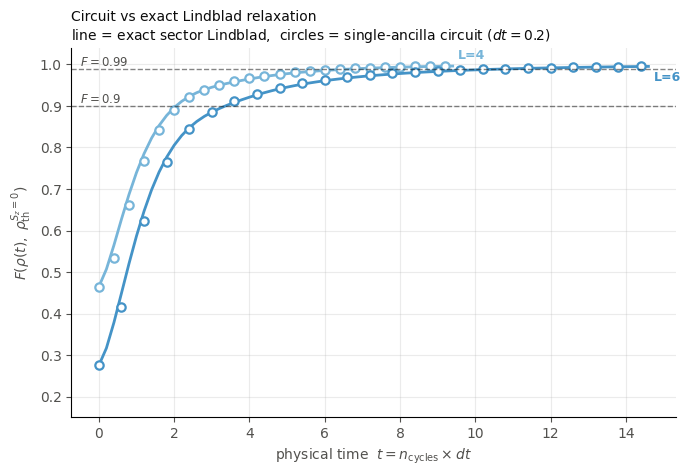

In [32]:
# ---- Does the CIRCUIT actually relax on this timescale? --------------------
# Everything above is the exact Lindblad equation. The circuit only reproduces it
# to first order in dt, so the timescales it inherits have to be checked, not
# assumed. Here the single-ancilla circuit is run at two sizes and its fidelity
# curve is laid over the exact sector-Lindblad prediction at the same physical
# times t = n * dt. The test that matters is not whether the two curves agree
# pointwise -- a first-order splitting cannot manage that during a steep rise --
# but whether the THRESHOLD TIMES agree, since those are what set n_cycles.

def fidelity_curve_exact(H_sec, L_sec, init_state, idx, times, T, dt_max=None):
    """F(rho(t), sector Gibbs) from the exact Lindblad equation, at the given times.

    Each requested time is landed on EXACTLY, by splitting the interval since the
    previous one into ceil(gap / dt_max) equal RK4 steps. Marching in fixed steps
    and stopping at the first one past t_want instead would leave the curve lagged
    by up to dt_max, which during the initial rise is worth ~0.1 in F -- enough to
    fake a disagreement with the circuit that is not there.
    """
    d = H_sec.shape[0]
    rho = basis_rho(init_state, idx, d)
    dt_max = rk4_dt(H_sec) if dt_max is None else dt_max
    rhs = lindblad_rhs(H_sec, L_sec)
    target = gibbs_sector(H_sec, T)

    out, t = [], 0.0
    for t_want in np.sort(np.asarray(times, dtype=float)):
        gap = t_want - t
        if gap > 1e-12:
            n = int(np.ceil(gap / dt_max))
            step = _rk4_stepper(rhs, gap / n)
            for _ in range(n):
                rho = step(rho)
            t = t_want
        out.append(uhlmann_fidelity(rho, target))
    return np.array(out)


def crossing(ts, ys, level):
    """First time ys rises through `level`, linearly interpolated (None if never)."""
    t0 = first_above(ts, ys, level)
    if t0 is None:
        return None
    k = int(np.argmax(np.asarray(ts) >= t0))
    if k == 0 or ys[k] == ys[k - 1]:
        return float(ts[k])
    f = (level - ys[k - 1]) / (ys[k] - ys[k - 1])
    return float(ts[k - 1] + f * (ts[k] - ts[k - 1]))


L_circ = [4, 6]        # density-matrix sim: L+1 qubits; L = 8 works but is slow
dt_trot = 0.2          # Trotter step; the dt^2 infidelity floor here is ~1e-4

fig, ax = plt.subplots(figsize=(7.8, 4.8))
print(f"{'L':>3}{'threshold':>12}{'circuit':>10}{'exact':>9}{'shift':>8}"
      f"{'max|dF|':>10}")
for L in L_circ:
    r = relax[L]
    init = r["init"]
    n_max = int(np.ceil(1.3 * r["times"]["t_F99"] / dt_trot))
    cycles = np.arange(0, n_max + 1)          # every cycle: one Aer run either way
    times = cycles * dt_trot

    H = get_schwinger_hamiltonian(L, m_mass, e_coup, a_lat)
    raw = [L_n(n=n, H=H, L=L, a=a_lat, T=T) for n in range(L)]
    eff = diagonalized_lindblad_ops(
        raw, D_matrix(L, a_lat, kind=D_kind, D0=D0, sigma=D_sigma), a_lat)
    one_step = build_single_ancilla_circuit(H_op=H, eff_L_ops=eff, n_sys=L,
                                            dt=dt_trot, n_steps=1)
    rho_target, Q = gibbs_dm(H, T, sector_of=init)
    F_circ = fidelity_vs_cycles(one_step, L, cycles, init, rho_target)

    H_sec, L_sec, idx = sector_ops(L, m_mass, e_coup, a_lat, T,
                                   D_kind=D_kind, D0=D0, D_sigma=D_sigma, Q0=Q0)
    F_exact = fidelity_curve_exact(H_sec, L_sec, init, idx, times, T)

    for key, lvl in F_LEVELS:
        tc, te = crossing(times, F_circ, lvl), crossing(times, F_exact, lvl)
        print(f"{L:>3}{key:>12}{tc:>10.2f}{te:>9.2f}{tc - te:>+8.2f}"
              f"{np.abs(F_circ - F_exact).max():>10.4f}")

    ax.plot(times, F_exact, "-", lw=2, color=shade(L))
    sub = slice(None, None, max(1, len(cycles) // 20))
    ax.plot(times[sub], F_circ[sub], "o", ms=6, mfc="white", mew=1.6,
            color=shade(L))
    # both curves finish at F ~ 1, so the end labels are nudged apart vertically
    ax.annotate(f"L={L}", (times[-1], F_exact[-1]), color=shade(L), fontsize=9,
                fontweight="bold", va="center", ha="left", annotation_clip=False,
                textcoords="offset points",
                xytext=(4, 8 if L == L_circ[0] else -8))

for _, y in F_LEVELS:
    ax.axhline(y, color=INK, lw=1.0, ls="--", alpha=0.5)
    ax.annotate(f"$F={y}$", (0.015, y), xycoords=("axes fraction", "data"),
                ha="left", va="bottom", fontsize=8.5, color=INK2)
ax.set_xlabel(r"physical time  $t = n_\mathrm{cycles}\times dt$", color=INK2)
ax.set_ylabel(r"$F(\rho(t),\ \rho_\mathrm{th}^{S_z=0})$", color=INK2)
ax.set_title("Circuit vs exact Lindblad relaxation\n"
             f"line = exact sector Lindblad,  circles = single-ancilla circuit "
             f"($dt={dt_trot}$)", color=INK, loc="left", fontsize=10)
ax.set_ylim(0.15, 1.04)
ax.grid(alpha=0.25, lw=0.8)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors=INK2)
fig.subplots_adjust(right=0.9)
plt.show()

Cost of thermalizing at Trotter dt = 0.2:

                              F >= 0.9            99% relaxed
  L  CNOTs/step    cycles        CNOTs    cycles        CNOTs
-------------------------------------------------------------
  2          26         8          208        69        1,794
  4          80        11          880       111        8,880
  6         142        18        2,556       199       28,258
  8         212        25        5,300       302       64,024
 10         290        32        9,280       408      118,320

  CNOTs/step ~ L^1.49   (structural: the ZZ's in H_elec)
      F >= 0.9:  cycles ~ L^0.88,  total ~ L^2.38,  208 -> 9,280 CNOTs
   99% relaxed:  cycles ~ L^1.12,  total ~ L^2.62,  1,794 -> 118,320 CNOTs


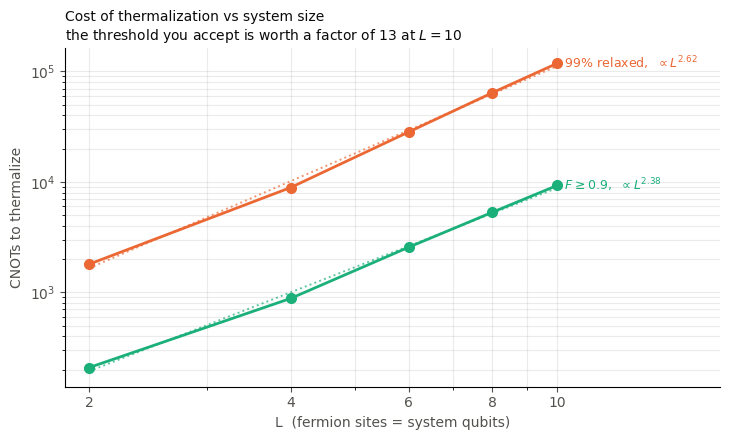

In [33]:
# ---- What thermalization time costs in gates -------------------------------
# The gate cost of preparing the thermal state factorises into the two things this
# notebook has now measured separately:
#
#     total CNOTs  =  (CNOTs per Trotter step)  x  (t_threshold / dt)
#                      ^ previous section          ^ this section
#
# The first factor is structural and grows like L^2 (H_elec puts a ZZ on every
# pair of sites). The second is dynamical. Neither alone tells you what a run
# costs. Which threshold to use is a choice, so both a loose one and a strict one
# are priced below.

COST_LEVELS = [("t_F90", "F >= 0.9", r"$F\geq0.9$"),
               ("t_99", "99% relaxed", "99% relaxed")]


def cx_per_step(L):
    """Structural CNOT count for one Trotter step at size L (see cx_model above)."""
    H = get_schwinger_hamiltonian(L, m_mass, e_coup, a_lat)
    raw = [L_n(n=n, H=H, L=L, a=a_lat, T=T) for n in range(L)]
    eff = diagonalized_lindblad_ops(
        raw, D_matrix(L, a_lat, kind=D_kind, D0=D0, sigma=D_sigma), a_lat)
    return cx_model(H) + sum(cx_model(build_J_operator([Lk], n_sys=L)) for Lk in eff)


per_step = {L: cx_per_step(L) for L in Ls_done}
cycles_for = {k: np.array([int(np.ceil(relax[L]["times"][k] / dt_trot))
                           for L in Ls_done]) for k, _, _ in COST_LEVELS}
total_for = {k: np.array([per_step[L] * c for L, c in zip(Ls_done, cycles_for[k])],
                         dtype=float) for k, _, _ in COST_LEVELS}

print(f"Cost of thermalizing at Trotter dt = {dt_trot}:\n")
print(f"{'':>15}" + "".join(f"{txt:>23}" for _, txt, _ in COST_LEVELS))
print(f"{'L':>3}{'CNOTs/step':>12}"
      + "".join(f"{'cycles':>10}{'CNOTs':>13}" for _ in COST_LEVELS))
print("-" * (15 + 23 * len(COST_LEVELS)))
for i, L in enumerate(Ls_done):
    row = f"{L:>3}{per_step[L]:>12}"
    for k, _, _ in COST_LEVELS:
        row += f"{cycles_for[k][i]:>10}{total_for[k][i]:>13,.0f}"
    print(row)

Lr = np.array(Ls_done, dtype=float)
p_step = float(np.polyfit(np.log(Lr), np.log([per_step[L] for L in Ls_done]), 1)[0])
print(f"\n  CNOTs/step ~ L^{p_step:.2f}   (structural: the ZZ's in H_elec)")
for k, txt, _ in COST_LEVELS:
    p_cyc = float(np.polyfit(np.log(Lr), np.log(cycles_for[k]), 1)[0])
    p_tot = float(np.polyfit(np.log(Lr), np.log(total_for[k]), 1)[0])
    print(f"  {txt:>12}:  cycles ~ L^{p_cyc:.2f},  total ~ L^{p_tot:.2f},  "
          f"{total_for[k][0]:,.0f} -> {total_for[k][-1]:,.0f} CNOTs")

fig, ax = plt.subplots(figsize=(7.4, 4.5))
for (k, _, lab), col in zip(COST_LEVELS, (C_F, C_D)):
    p = float(np.polyfit(np.log(Lr), np.log(total_for[k]), 1)[0])
    A = np.exp(np.polyfit(np.log(Lr), np.log(total_for[k]), 1)[1])
    ax.loglog(Lr, total_for[k], "-o", color=col, lw=2, ms=7)
    ax.loglog(Lr, A * Lr ** p, ":", color=col, lw=1.4, alpha=0.7)
    ax.annotate(f"  {lab},  $\\propto L^{{{p:.2f}}}$", (Lr[-1], total_for[k][-1]),
                color=col, fontsize=9, va="center", ha="left", annotation_clip=False)
ax.set_xticks(Ls_done)
ax.set_xticklabels([str(L) for L in Ls_done])
ax.xaxis.set_minor_formatter(plt.NullFormatter())   # log scale wants to label 3x10^0
ax.set_xlim(Lr[0] * 0.92, Lr[-1] * 1.75)
ax.set_xlabel("L  (fermion sites = system qubits)", color=INK2)
ax.set_ylabel("CNOTs to thermalize", color=INK2)
ax.set_title("Cost of thermalization vs system size\n"
             "the threshold you accept is worth a factor of "
             f"{total_for['t_99'][-1] / total_for['t_F90'][-1]:.0f} at $L={Ls_done[-1]}$",
             color=INK, loc="left", fontsize=10)
ax.grid(alpha=0.25, lw=0.8, which="both")
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors=INK2)
plt.tight_layout()
plt.show()

### What the sweep says

Measured at $m = 0.5$, $e = 0.71$, $T = 5$, delta correlator with $D_0 = 1$, starting
from $|0101\ldots\rangle$ (the $S_z = 0$ sector). Times are in lattice units, $a = 1$,
and resolved to $\pm 0.25$ — the sampling interval `sample_dt`.

| $L$ | $d_\mathrm{sec}$ | $dt_\mathrm{RK4}$ | $t_{50}$ | $t_{90}$ | $t_{99}$ | $t_{F\geq0.9}$ | $t_{F\geq0.99}$ | $t_{99}/t_{90}$ |
|---|---|---|---|---|---|---|---|---|
| 2 | 2 | 0.719 | 2.2 | 7.2 | 13.7 | 1.4 | 3.6 | 1.90 |
| 4 | 6 | 0.300 | 1.8 | 8.7 | 22.2 | 2.1 | 7.2 | 2.55 |
| 6 | 20 | 0.189 | 2.1 | 12.7 | 39.7 | 3.4 | 11.2 | 3.13 |
| 8 | 70 | 0.138 | 2.8 | 16.6 | 60.3 | 5.0 | 16.3 | 3.63 |
| 10 | 252 | 0.105 | 3.6 | 21.5 | 81.6 | 6.3 | 21.9 | 3.79 |

**"Thermalized" is not one number.** At $L = 10$ the five thresholds span a factor of
23, from $t_{F\geq0.9} = 6.3$ to $t_{99} = 81.6$. There is no way to quote *the*
relaxation time without first saying how close to thermal is close enough — the
choice is worth more than an order of magnitude in run length, and at $dt = 0.2$ it
is the difference between 32 cycles and 408.

**Only the tail slows down.** $t_{50}$ is essentially flat across the whole sweep:
$2.2 \to 3.6$ over five sizes, with $R^2 < 0.5$ for a power law and $< 0.71$ for an
exponential — no fit describes it, because there is barely a trend to fit. Getting
*halfway* to thermal costs about the same at $L=10$ as at $L=2$. Everything that
grows with $L$ lives in the approach: $t_{90}$ grows by $3.0\times$, $t_{99}$ by
$6.0\times$, and the ratio $t_{99}/t_{90}$ climbs monotonically from 1.90 to 3.79.
The relaxation is not a single exponential — it is a fast, size-insensitive initial
collapse onto a slower tail, and the tail is what lengthens with $L$. Panel 1 of the
figure shows this directly: the curves all leave $D=1$ together and only fan out
below $D \approx 0.3$.

**Power law or exponential?** Over this range the exponential fits marginally better
for three of the four series that have a trend at all, but not decisively:

| series | $\propto L^{p}$ | $R^2$ | $\propto e^{cL}$ | $R^2$ | better |
|---|---|---|---|---|---|
| $t_{50}$ | $p = 0.30$ | 0.484 | $c = 0.072$ | 0.707 | *no clear trend* |
| $t_{90}$ | $p = 0.68$ | 0.928 | $c = 0.142$ | 0.992 | exponential |
| $t_{99}$ | $p = 1.13$ | 0.972 | $c = 0.229$ | 0.988 | exponential |
| $t_{F\geq0.9}$ | $p = 0.94$ | 0.966 | $c = 0.191$ | 0.989 | exponential |
| $t_{F\geq0.99}$ | $p = 1.12$ | 0.996 | $c = 0.222$ | 0.972 | power law |

Five sizes spanning half a decade in $L$ cannot separate $L^{1.1}$ from $e^{0.23L}$;
the two forms differ by less than the curvature this data resolves, and $t_{F\geq0.99}$
preferring the power law while $t_{99}$ prefers the exponential is a sign the
comparison is at the noise level, not a real distinction. Read the exponents as a
trend. What is safe to say is that the practical thermalization time grows roughly
*linearly* in $L$ over this range.

**The circuit relaxes on the same clock.** At $dt = 0.2$ the single-ancilla circuit's
fidelity curve tracks the exact sector-Lindblad curve to within 0.031 ($L=4$) and
0.033 ($L=6$) pointwise. The pointwise gap is not really the test, though — what
matters is whether the *threshold times* survive, and they do: the circuit reaches
$F \geq 0.9$ within $0.06$ of the exact prediction and $F \geq 0.99$ within $0.43$,
against times of 2–11. So the table above is a statement about the circuit and not
just about the master equation, and $n_\mathrm{cycles} \approx t_\mathrm{threshold}/dt$
is the right way to budget.

**The gate cost.** Folding the two measured factors together at $dt = 0.2$:

| threshold | CNOTs/step | cycles | total | $L=2 \to L=10$ |
|---|---|---|---|---|
| $F \geq 0.9$ | $\sim L^{1.49}$ | $\sim L^{0.88}$ | $\sim L^{2.38}$ | 208 → 9,280 |
| 99% relaxed | $\sim L^{1.49}$ | $\sim L^{1.12}$ | $\sim L^{2.62}$ | 1,794 → 118,320 |

The structural factor dominates the scaling — the circuit gets more expensive with
$L$ mostly because each Trotter step does ($ZZ$ on every pair of sites in
$H_\mathrm{elec}$), not because it needs proportionally more steps. But the threshold
you accept is worth a flat factor of 13 in total gates at $L=10$, which is larger than
anything the scaling exponents buy over this range.

**The fixed point is the thermal state, but only nearly.** $F(\rho_\mathrm{ss},
\rho_\mathrm{th}^{S_z=0}) = 1.000000$ to six digits at every size, so the
high-temperature construction has not degraded even though $\|H\|$ grows with $L$ at
fixed $T$ — the slowdown is a property of the dynamics, not of the target drifting.
It is not exact, though: $\|\mathcal{L}[\rho_\mathrm{th}]\| \approx 3\text{–}5\times10^{-4}$
and $\|\rho_\mathrm{ss} - \rho_\mathrm{th}\|_1 \approx 2\text{–}3\times10^{-4}$, because
$L(n) = O(n) - [H, O(n)]/4T$ is only detailed-balanced to leading order in $1/T$. That
is why $\rho_\mathrm{ss}$ is found by evolving rather than assumed: substituting
$\rho_\mathrm{th}$ would put a floor on $D(t)$ right about where $t_{99}$ is being read.

**Validation.** At $L=4$ the sector RK4 trajectory was compared against exact
$e^{\mathcal{L}t}$ on the full $256\times256$ Liouvillian. No weight leaves the sector
($2\times10^{-16}$), and the difference between the two converges to *zero* as $dt^4$
($6.4\times10^{-5} \to 1.3\times10^{-8}$, falling by $\approx16$ per halving) rather
than to a floor — so the charge-sector restriction introduces no error of its own, and
the default step size is worth $\sim 10^{-7}$ on $\rho$ at that size.

**Caveats worth keeping in view.**
- **This is the staggered state's relaxation time, not the model's.** A different
  $S_z=0$ starting state would give different numbers — that is the whole point of
  measuring the state rather than the Liouvillian spectrum. Extending the sweep over
  initial states is the natural next step.
- Everything is quoted for the $S_z = 0$ sector. The full Liouvillian has one
  stationary state *per* sector (5 of them at $L=4$), so there is no unique fixed
  point on the full Hilbert space and no sector-independent relaxation time.
- $D_0$ sets the overall rate — doubling it halves every time in the table. Only the
  $L$-*dependence* is the physics.
- Holding $a$ and $e$ fixed while growing $L$ grows the physical volume *and* the
  accumulated electric energy. The fixed-physical-volume question ($a \sim 1/L$, the
  continuum limit) is a different scaling study and need not give the same answer.
- `D_floor = 1e-3` caps how deep the trace-distance curve is measured, which is what
  makes $t_{99}$ the strictest threshold available. A $t_{99.9}$ would need `D_floor`
  lowered, at proportionate cost.
- $L = 10$ is 8.5 minutes of the sweep's 9; $L = 12$ ($d_\mathrm{sec} = 924$) is
  roughly another factor of 25 and wants to move out of a notebook.